# HVFHV Sample EDA

This notebook is the exploratory data analysis for the HVFHV portion of the NYC congestion pricing project.

The goal is to mirror the Yellow Taxi EDA structure while using HVFHV-specific fields: provider license, shared-ride flags, driver pay, base passenger fare, booking-company fee, and itemized HVFHV cost components.

**Primary data used here:** `data/processed/samples/trip_level_sample_20k_representative.csv`

This file contains both Yellow Taxi and HVFHV rows. This notebook isolates `service_type == "hvfhv"` and treats the resulting rows as the first-step cleaned HVFHV sample.

**Optional helper-rich copy produced here:** `data/processed/samples/hvfhv_trip_level_sample_eda_features.csv`

This export contains the same HVFHV rows plus convenience fields created during EDA. These fields are diagnostic and should not be confused with the first-step cleaning output.

**Sampling note:** this is a representative sample stratified by `service_type x year x month`. For aggregate percentages or means, this notebook uses `sample_weight` when possible.

## 0. Data Layers, Policy Timing, and Analysis Rules

This notebook separates two different issues: **what data layer we are using** and **how policy-facing metrics should be interpreted**.

**Data layers:**

1. **First-step cleaned sample:** rows retained after the team's conservative validity filters and sampled for EDA.
2. **EDA helper fields:** labels, buckets, ratios, and flags created inside this notebook to make patterns easier to inspect.

**Analysis rules:**

1. **Policy timing rule:** the CBD congestion fee is a post-policy variable. A 2024 CBD fee or burden average is a sanity check, not a substantive policy metric.
2. **Analysis inclusion rule:** different questions use different subsets. Burden analysis uses post-policy charged trips with a positive denominator. Distance/rate analysis excludes zero-distance rows.
3. **HVFHV provider rule:** provider and shared-ride fields are descriptive regimes. They help explain patterns but are not row-dropping cleaning rules by themselves.

**Time frame used in this notebook:**

- Pre-policy comparison window: February-June 2024.
- Post-policy window: February-June 2025.
- January 2025 is excluded because the CBD congestion pricing policy began on January 5, 2025, so January is a transition month.
- Matching the same calendar months reduces seasonality problems.

**Team first-step cleaning rules used before sampling:**

- parse pickup/dropoff timestamps;
- keep rows with `dropoff_datetime > pickup_datetime`;
- keep rows whose pickup year/month match the source file;
- require non-missing pickup and dropoff zone IDs;
- require nonnegative trip distance;
- require positive trip duration;
- require non-missing, nonnegative `cbd_congestion_fee` after filling pre-policy 2024 missing values with 0;
- require positive `passenger_cost_pretip`.

**Main HVFHV analysis rules suggested by this EDA:**

- main burden analysis should use 2025 charged trips with `base_cost_ex_cbd > 0`;
- base-cost denominators below $1 should be flagged for sensitivity checks;
- zero-distance trips should be retained as flagged records in the broad sample but excluded from distance-, speed-, and per-mile analyses;
- provider and shared-ride composition should be reported alongside burden metrics;
- final policy-facing summaries should be checked on full-data monthly/zone aggregates, not only on this 20K sample.

## 1. Setup

This section loads the 20K representative sample, isolates HVFHV rows, creates helper fields, and defines weighted summary functions. Because the sample is stratified, weighted summaries are safer than raw row percentages when describing the underlying cleaned HVFHV population.

In [1]:
from pathlib import Path
import os
import warnings

CWD = Path.cwd().resolve()
CACHE_ROOT = CWD if (CWD / "data").exists() else CWD.parent
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_ROOT / ".matplotlib-cache"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

SAMPLE_REL_PATH = Path("data/processed/samples/trip_level_sample_20k_representative.csv")
DIAGNOSTIC_REL_PATH = Path("data/processed/samples/trip_level_sample_5k_diagnostic.csv")
ZONE_LOOKUP_REL_PATH = Path("data/taxi_zone_lookup.csv")

for candidate in [CWD, CWD.parent]:
    if (candidate / SAMPLE_REL_PATH).exists():
        REPO_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find trip_level_sample_20k_representative.csv from the "
        "current notebook working directory or its parent."
    )

SAMPLE_PATH = REPO_ROOT / SAMPLE_REL_PATH
DIAGNOSTIC_PATH = REPO_ROOT / DIAGNOSTIC_REL_PATH
ZONE_LOOKUP_PATH = REPO_ROOT / ZONE_LOOKUP_REL_PATH

all_sample = pd.read_csv(
    SAMPLE_PATH,
    parse_dates=["pickup_datetime", "dropoff_datetime", "pickup_date"],
    low_memory=False,
)

sample = all_sample.loc[all_sample["service_type"].eq("hvfhv")].copy()

if sample.empty:
    raise ValueError("The representative sample contains no HVFHV rows.")

print(f"Repository root: {REPO_ROOT}")
print(f"All representative-sample rows: {len(all_sample):,}")
print(f"HVFHV rows: {len(sample):,}")
print(f"HVFHV share of sample: {len(sample) / len(all_sample):.2%}")

sample.head()

Repository root: /Users/ping/Documents/GitHub/summer26-congestion-pricing
All representative-sample rows: 20,000
HVFHV rows: 16,889
HVFHV share of sample: 84.45%


,sample_row_id,sampling_stratum,stratum_population_n,stratum_sample_n,sample_weight,service_type,year,month,pickup_datetime,dropoff_datetime,pickup_date,pickup_hour,day_of_week,PULocationID,DOLocationID,trip_distance_miles,trip_duration_seconds,cbd_congestion_fee,charged_cbd_flag,congestion_surcharge,tolls,airport_fee,passenger_cost_pretip,passenger_cost_excl_cbd,relative_cbd_burden,source_file,payment_type,passenger_count,fare_amount,tip_amount,total_amount,RatecodeID,yellow_payment_type_label,yellow_card_or_cash_flag,yellow_no_charge_dispute_void_flag,yellow_payment_unknown_flag,yellow_payment_review_flag,hvfhs_license_num,base_passenger_fare,bcf,sales_tax,tips,driver_pay,shared_request_flag,shared_match_flag,burden_eligible_flag,passenger_cost_nonpositive_flag,negative_cbd_fee_flag,zero_distance_flag,very_long_duration_flag,very_long_distance_flag,negative_distance_flag,nonpositive_duration_flag,invalid_timestamp_flag,month_mismatch_flag,missing_zone_flag,any_negative_cost_component_flag,possible_refund_or_adjustment_flag,dst_transition_day_flag,dst_transition_window_flag,negative_cost_flag
0,1,hvfhv_2024_02,19352998,1620,"11,946.2951",hvfhv,2024,2,2024-02-01 01:55:05,2024-02-01 02:04:34,2024-02-01,1,3,74,74,1.1120,569.0000,0.0000,False,0.0000,0.0000,0.0000,8.9900,8.9900,0.0000,data/raw/2024/Feb/fhvhv_tripdata_2024-02.parquet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,HV0005,8.0600,0.2200,0.7100,0.0000,6.8800,N,N,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,2,hvfhv_2024_02,19352998,1620,"11,946.2951",hvfhv,2024,2,2024-02-01 02:40:15,2024-02-01 02:50:11,2024-02-01,2,3,263,170,3.0430,596.0000,0.0000,False,2.7500,0.0000,0.0000,18.9900,18.9900,0.0000,data/raw/2024/Feb/fhvhv_tripdata_2024-02.parquet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,HV0005,14.5500,0.4000,1.2900,0.0000,9.6800,N,N,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,3,hvfhv_2024_02,19352998,1620,"11,946.2951",hvfhv,2024,2,2024-02-01 03:53:28,2024-02-01 04:09:24,2024-02-01,3,3,262,138,8.2000,956.0000,0.0000,False,2.7500,6.9400,2.5000,66.8700,66.8700,0.0000,data/raw/2024/Feb/fhvhv_tripdata_2024-02.parquet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,HV0003,48.0000,1.5800,5.1000,0.0000,34.5600,N,N,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,4,hvfhv_2024_02,19352998,1620,"11,946.2951",hvfhv,2024,2,2024-02-01 07:13:55,2024-02-01 07:40:19,2024-02-01,7,3,69,41,3.9850,"1,584.0000",0.0000,False,0.0000,0.0000,0.0000,25.9900,25.9900,0.0000,data/raw/2024/Feb/fhvhv_tripdata_2024-02.parquet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,HV0005,23.2800,0.6400,2.0700,0.0000,20.3000,N,N,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,5,hvfhv_2024_02,19352998,1620,"11,946.2951",hvfhv,2024,2,2024-02-01 07:02:06,2024-02-01 07:42:03,2024-02-01,7,3,257,170,10.4540,"2,397.0000",0.0000,False,2.7500,5.8800,0.0000,59.2500,59.2500,0.0000,data/raw/2024/Feb/fhvhv_tripdata_2024-02.parquet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,HV0005,44.7400,1.3900,4.4900,0.0000,36.5700,N,N,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [2]:
# EDA helper fields created from the first-step cleaned HVFHV sample.
# These are not additional row-dropping cleaning rules.
PROVIDER_LABELS = {
    "HV0003": "Uber",
    "HV0005": "Lyft",
    "HV0002": "Juno",
    "HV0004": "Via",
}

sample["provider_label"] = (
    sample["hvfhs_license_num"]
    .map(PROVIDER_LABELS)
    .fillna(sample["hvfhs_license_num"])
    .fillna("Missing")
)

for col in [
    "trip_distance_miles",
    "trip_duration_seconds",
    "cbd_congestion_fee",
    "passenger_cost_pretip",
    "passenger_cost_excl_cbd",
    "base_passenger_fare",
    "bcf",
    "sales_tax",
    "congestion_surcharge",
    "tolls",
    "airport_fee",
    "tips",
    "driver_pay",
]:
    sample[col] = pd.to_numeric(sample[col], errors="coerce")

sample["pre_policy_flag"] = sample["year"].eq(2024)
sample["post_policy_flag"] = sample["year"].eq(2025)
sample["charged_cbd_flag"] = sample["cbd_congestion_fee"].gt(0)
sample["post_policy_charged_cbd_flag"] = sample["post_policy_flag"] & sample["charged_cbd_flag"]

sample["pickup_hour"] = sample["pickup_datetime"].dt.hour
sample["pickup_weekday"] = sample["pickup_datetime"].dt.day_name()
sample["trip_duration_minutes"] = sample["trip_duration_seconds"] / 60

sample["base_cost_ex_cbd"] = (
    sample["passenger_cost_pretip"] - sample["cbd_congestion_fee"]
).round(2)

sample["relative_cbd_burden_current_cost"] = np.where(
    sample["charged_cbd_flag"] & sample["passenger_cost_pretip"].gt(0),
    sample["cbd_congestion_fee"] / sample["passenger_cost_pretip"],
    np.nan,
)

sample["relative_cbd_burden_base_cost"] = np.where(
    sample["charged_cbd_flag"] & sample["base_cost_ex_cbd"].gt(0),
    sample["cbd_congestion_fee"] / sample["base_cost_ex_cbd"],
    np.nan,
)

sample["gross_cost_per_mile"] = np.where(
    sample["trip_distance_miles"].gt(0),
    sample["passenger_cost_pretip"] / sample["trip_distance_miles"],
    np.nan,
)

sample["driver_pay_per_mile"] = np.where(
    sample["trip_distance_miles"].gt(0),
    sample["driver_pay"] / sample["trip_distance_miles"],
    np.nan,
)

sample["driver_pay_per_hour"] = np.where(
    sample["trip_duration_seconds"].gt(0),
    sample["driver_pay"] / (sample["trip_duration_seconds"] / 3600),
    np.nan,
)

sample["speed_mph"] = np.where(
    sample["trip_duration_seconds"].gt(0),
    sample["trip_distance_miles"] / (sample["trip_duration_seconds"] / 3600),
    np.nan,
)

sample["shared_request_normalized"] = (
    sample["shared_request_flag"].astype("string").str.strip().str.upper()
    .replace({"TRUE": "Y", "FALSE": "N"})
)
sample["shared_match_normalized"] = (
    sample["shared_match_flag"].astype("string").str.strip().str.upper()
    .replace({"TRUE": "Y", "FALSE": "N"})
)
sample["shared_request_yes_flag"] = sample["shared_request_normalized"].eq("Y")
sample["shared_match_yes_flag"] = sample["shared_match_normalized"].eq("Y")

sample["main_analysis_flag"] = (
    sample["PULocationID"].notna()
    & sample["DOLocationID"].notna()
    & sample["trip_duration_seconds"].gt(0)
    & sample["trip_distance_miles"].ge(0)
    & sample["cbd_congestion_fee"].ge(0)
    & sample["passenger_cost_pretip"].gt(0)
)

sample["burden_analysis_flag"] = (
    sample["main_analysis_flag"]
    & sample["post_policy_charged_cbd_flag"]
    & sample["base_cost_ex_cbd"].gt(0)
)

sample["distance_rate_analysis_flag"] = (
    sample["main_analysis_flag"]
    & sample["trip_distance_miles"].gt(0)
)

sample.head()

,sample_row_id,sampling_stratum,stratum_population_n,stratum_sample_n,sample_weight,service_type,year,month,pickup_datetime,dropoff_datetime,pickup_date,pickup_hour,day_of_week,PULocationID,DOLocationID,trip_distance_miles,trip_duration_seconds,cbd_congestion_fee,charged_cbd_flag,congestion_surcharge,tolls,airport_fee,passenger_cost_pretip,passenger_cost_excl_cbd,relative_cbd_burden,source_file,payment_type,passenger_count,fare_amount,tip_amount,total_amount,RatecodeID,yellow_payment_type_label,yellow_card_or_cash_flag,yellow_no_charge_dispute_void_flag,yellow_payment_unknown_flag,yellow_payment_review_flag,hvfhs_license_num,base_passenger_fare,bcf,sales_tax,tips,driver_pay,shared_request_flag,shared_match_flag,burden_eligible_flag,passenger_cost_nonpositive_flag,negative_cbd_fee_flag,zero_distance_flag,very_long_duration_flag,very_long_distance_flag,negative_distance_flag,nonpositive_duration_flag,invalid_timestamp_flag,month_mismatch_flag,missing_zone_flag,any_negative_cost_component_flag,possible_refund_or_adjustment_flag,dst_transition_day_flag,dst_transition_window_flag,negative_cost_flag,provider_label,pre_policy_flag,post_policy_flag,post_policy_charged_cbd_flag,pickup_weekday,trip_duration_minutes,base_cost_ex_cbd,relative_cbd_burden_current_cost,relative_cbd_burden_base_cost,gross_cost_per_mile,driver_pay_per_mile,driver_pay_per_hour,speed_mph,shared_request_normalized,shared_match_normalized,shared_request_yes_flag,shared_match_yes_flag,main_analysis_flag,burden_analysis_flag,distance_rate_analysis_flag
0,1,hvfhv_2024_02,19352998,1620,"11,946.2951",hvfhv,2024,2,2024-02-01 01:55:05,2024-02-01 02:04:34,2024-02-01,1,3,74,74,1.1120,569.0000,0.0000,False,0.0000,0.0000,0.0000,8.9900,8.9900,0.0000,data/raw/2024/Feb/fhvhv_tripdata_2024-02.parquet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,HV0005,8.0600,0.2200,0.7100,0.0000,6.8800,N,N,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Lyft,True,False,False,Thursday,9.4833,8.9900,NaN,NaN,8.0845,6.1871,43.5290,7.0355,N,N,False,False,True,False,True
1,2,hvfhv_2024_02,19352998,1620,"11,946.2951",hvfhv,2024,2,2024-02-01 02:40:15,2024-02-01 02:50:11,2024-02-01,2,3,263,170,3.0430,596.0000,0.0000,False,2.7500,0.0000,0.0000,18.9900,18.9900,0.0000,data/raw/2024/Feb/fhvhv_tripdata_2024-02.parquet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,HV0005,14.5500,0.4000,1.2900,0.0000,9.6800,N,N,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Lyft,True,False,False,Thursday,9.9333,18.9900,NaN,NaN,6.2406,3.1811,58.4698,18.3805,N,N,False,False,True,False,True
2,3,hvfhv_2024_02,19352998,1620,"11,946.2951",hvfhv,2024,2,2024-02-01 03:53:28,2024-02-01 04:09:24,2024-02-01,3,3,262,138,8.2000,956.0000,0.0000,False,2.7500,6.9400,2.5000,66.8700,66.8700,0.0000,data/raw/2024/Feb/fhvhv_tripdata_2024-02.parquet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,HV0003,48.0000,1.5800,5.1000,0.0000,34.5600,N,N,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Uber,True,False,False,Thursday,15.9333,66.8700,NaN,NaN,8.1549,4.2146,130.1423,30.8787,N,N,False,False,True,False,True
3,4,hvfhv_2024_02,19352998,1620,"11,946.2951",hvfhv,2024,2,2024-02-01 07:13:55,2024-02-01 07:40:19,2024-02-01,7,3,69,41,3.9850,"1,584.0000",0.0000,False,0.0000,0.0000,0.0000,25.9900,25.9900,0.0000,data/raw/2024/Feb/fhvhv_tripdata_2024-02.parquet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,HV0005,23.2800,0.6400,2.0700,0.0000,20.3000,N,N,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Lyft,True,False,False,Thursday,26.4000,25.9900,NaN,NaN,6.5220,5.0941,46.1364,9.0568,N,N,False,False,True,False,True
4,5,hvfhv_2024_02,19352998,1620,"11,946.2951",hvfhv,2024,2,2024-02-01 07:02:06,2024-02-01 07:42:03,2024-02-01,7,3,257,170,10.4540,"2,397.0000",0.0000,False,2.7500,5.8800,0.0000,59.2500,59.2500,0.0000,data/raw/2024/Feb/fhvhv_tripdata_2024-02.parqu

In [3]:
def weighted_mean(x, w):
    x = pd.to_numeric(x, errors="coerce")
    w = pd.to_numeric(w, errors="coerce")
    mask = x.notna() & w.notna() & w.gt(0)
    if mask.sum() == 0:
        return np.nan
    return np.average(x[mask], weights=w[mask])


def weighted_share(mask, w):
    mask = pd.Series(mask, index=w.index).fillna(False).astype(bool)
    w = pd.to_numeric(w, errors="coerce")
    valid = w.notna() & w.gt(0)
    if valid.sum() == 0:
        return np.nan
    return w[valid & mask].sum() / w[valid].sum()


def weighted_quantile(values, weights, quantiles):
    values = pd.to_numeric(pd.Series(values), errors="coerce")
    weights = pd.to_numeric(pd.Series(weights), errors="coerce")
    mask = values.notna() & weights.notna() & weights.gt(0)
    values = values[mask].to_numpy()
    weights = weights[mask].to_numpy()
    if len(values) == 0:
        return [np.nan for _ in quantiles]
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cum_weights = np.cumsum(weights) - 0.5 * weights
    cum_weights = cum_weights / weights.sum()
    return np.interp(quantiles, cum_weights, values)


def weighted_summary(df, value_col, group_cols=None):
    if group_cols is None:
        group_cols = []
    rows = []
    grouped = [("all", df)] if not group_cols else df.groupby(group_cols, dropna=False)
    for key, g in grouped:
        q25, q50, q75 = weighted_quantile(g[value_col], g["sample_weight"], [0.25, 0.5, 0.75])
        rows.append({
            "group": key,
            "weighted_mean": weighted_mean(g[value_col], g["sample_weight"]),
            "weighted_p25": q25,
            "weighted_median": q50,
            "weighted_p75": q75,
            "unweighted_n": len(g),
            "estimated_population": g["sample_weight"].sum(),
        })
    return pd.DataFrame(rows)


def save_table(frame, filename):
    # Sample-EDA is a display-only diagnostic (like yellow_taxi_sample_EDA); nothing is written to disk.
    from IPython.display import display
    display(frame)


def save_figure(filename):
    plt.tight_layout()

Rows: 16,889
Columns: 81


,year,month,sample_rows,estimated_population
0,2024,2,1620,"19,352,998.0000"
1,2024,3,1782,"21,279,860.0000"
2,2024,4,1652,"19,732,410.0000"
3,2024,5,1734,"20,704,206.0000"
4,2024,6,1685,"20,122,914.0000"
5,2025,2,1619,"19,338,054.0000"
6,2025,3,1715,"20,477,120.0000"
7,2025,4,1653,"19,741,018.0000"
8,2025,5,1766,"21,090,841.0000"
9,2025,6,1663,"19,856,429.0000"


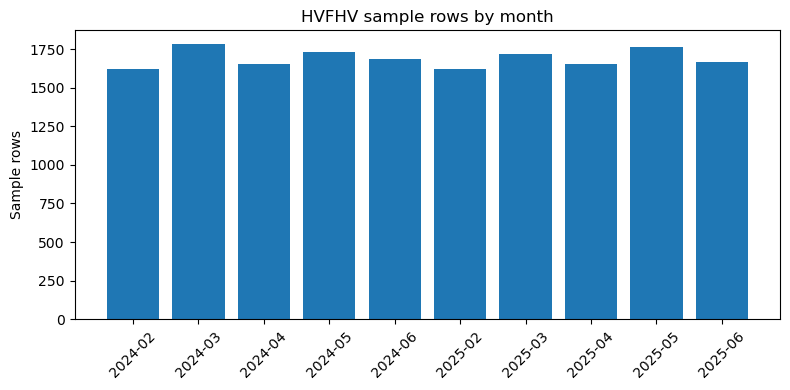

In [4]:
print(f"Rows: {sample.shape[0]:,}")
print(f"Columns: {sample.shape[1]:,}")

sample_by_month = (
    sample.groupby(["year", "month"], as_index=False)
    .agg(
        sample_rows=("sample_row_id", "size"),
        estimated_population=("sample_weight", "sum"),
    )
)

display(sample_by_month)

fig, ax = plt.subplots(figsize=(8, 4))
labels = sample_by_month["year"].astype(str) + "-" + sample_by_month["month"].astype(str).str.zfill(2)
ax.bar(labels, sample_by_month["sample_rows"])
ax.set_title("HVFHV sample rows by month")
ax.set_ylabel("Sample rows")
ax.tick_params(axis="x", rotation=45)
save_figure("hvfhv_sample_rows_by_month.png")
plt.show()

## 2. Missingness Check

This section follows the Yellow Taxi notebook's missingness pass: first review the whole sample, then inspect selected analysis fields, then check whether missingness is concentrated by provider or year.

In [5]:
missing_summary = pd.DataFrame({
    "missing_count": sample.isna().sum(),
    "missing_pct": 100 * sample.isna().mean(),
}).sort_values("missing_pct", ascending=False)

missing_summary = missing_summary[missing_summary["missing_count"] > 0]
display(missing_summary)
save_table(missing_summary.reset_index(names="column"), "hvfhv_missingness_all_columns.csv")

,missing_count,missing_pct
payment_type,16889,100.0000
passenger_count,16889,100.0000
fare_amount,16889,100.0000
tip_amount,16889,100.0000
total_amount,16889,100.0000
RatecodeID,16889,100.0000
yellow_payment_type_label,16889,100.0000
relative_cbd_burden_base_cost,13935,82.5093
relative_cbd_burden_current_cost,13935,82.5093
driver_pay_per_mile,1,0.0059


,column,missing_count,missing_pct
0,payment_type,16889,100.0000
1,passenger_count,16889,100.0000
2,fare_amount,16889,100.0000
3,tip_amount,16889,100.0000
4,total_amount,16889,100.0000
5,RatecodeID,16889,100.0000
6,yellow_payment_type_label,16889,100.0000
7,relative_cbd_burden_base_cost,13935,82.5093
8,relative_cbd_burden_current_cost,13935,82.5093
9,driver_pay_per_mile,1,0.0059


In [6]:
selected_missing_cols = [
    "hvfhs_license_num",
    "PULocationID",
    "DOLocationID",
    "trip_distance_miles",
    "trip_duration_seconds",
    "passenger_cost_pretip",
    "passenger_cost_excl_cbd",
    "cbd_congestion_fee",
    "base_passenger_fare",
    "bcf",
    "sales_tax",
    "congestion_surcharge",
    "tolls",
    "airport_fee",
    "tips",
    "driver_pay",
    "shared_request_flag",
    "shared_match_flag",
]

missing_by_provider = (
    sample.groupby(["year", "provider_label"], dropna=False)
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "weighted_missing_driver_pay_pct": 100 * weighted_share(g["driver_pay"].isna(), g["sample_weight"]),
        "weighted_missing_shared_request_pct": 100 * weighted_share(g["shared_request_flag"].isna(), g["sample_weight"]),
        "weighted_missing_base_fare_pct": 100 * weighted_share(g["base_passenger_fare"].isna(), g["sample_weight"]),
    }), include_groups=False)
    .reset_index()
)

display(missing_by_provider)
save_table(missing_by_provider, "hvfhv_missingness_by_provider.csv")

,year,provider_label,sample_rows,weighted_missing_driver_pay_pct,weighted_missing_shared_request_pct,weighted_missing_base_fare_pct
0,2024,Lyft,"2,210.0000",0.0000,0.0000,0.0000
1,2024,Uber,"6,263.0000",0.0000,0.0000,0.0000
2,2025,Lyft,"2,283.0000",0.0000,0.0000,0.0000
3,2025,Uber,"6,133.0000",0.0000,0.0000,0.0000


,year,provider_label,sample_rows,weighted_missing_driver_pay_pct,weighted_missing_shared_request_pct,weighted_missing_base_fare_pct
0,2024,Lyft,"2,210.0000",0.0000,0.0000,0.0000
1,2024,Uber,"6,263.0000",0.0000,0.0000,0.0000
2,2025,Lyft,"2,283.0000",0.0000,0.0000,0.0000
3,2025,Uber,"6,133.0000",0.0000,0.0000,0.0000


In [7]:
missing_cols = [c for c in selected_missing_cols if sample[c].isna().any()]

if missing_cols:
    plot_df = sample.sort_values(["provider_label", "year", "month", "sample_row_id"]).reset_index(drop=True)
    missing_matrix = plot_df[missing_cols].isna().astype(int)

    fig, ax = plt.subplots(figsize=(max(7, 0.45 * len(missing_cols)), 5))
    ax.imshow(missing_matrix, aspect="auto", interpolation="nearest", cmap="Greys")
    ax.set_title("Missingness matrix - HVFHV selected fields")
    ax.set_xlabel("Column")
    ax.set_ylabel("Sorted sample rows")
    ax.set_xticks(range(len(missing_cols)))
    ax.set_xticklabels(missing_cols, rotation=90)
    save_figure("hvfhv_missingness_matrix.png")
    plt.show()
else:
    print("No missing values found in selected HVFHV analysis fields.")

No missing values found in selected HVFHV analysis fields.


## 3. Cleaning Sanity Checks

This section checks whether major invalid records remain and identifies rows that are valid but should be flagged for sensitivity checks. The broad sample is retained; analysis-specific masks are created later.

In [8]:
flag_cols = [
    "zero_distance_flag",
    "very_long_duration_flag",
    "very_long_distance_flag",
    "negative_distance_flag",
    "nonpositive_duration_flag",
    "invalid_timestamp_flag",
    "month_mismatch_flag",
    "missing_zone_flag",
    "negative_cbd_fee_flag",
    "passenger_cost_nonpositive_flag",
    "any_negative_cost_component_flag",
    "possible_refund_or_adjustment_flag",
    "dst_transition_day_flag",
    "dst_transition_window_flag",
    "negative_cost_flag",
]

flag_rows = []
for col in flag_cols:
    if col in sample.columns:
        flag_rows.append({
            "flag": col,
            "sample_rows": sample[col].fillna(False).astype(bool).sum(),
            "sample_pct": 100 * sample[col].fillna(False).astype(bool).mean(),
            "weighted_pct": 100 * weighted_share(sample[col].fillna(False).astype(bool), sample["sample_weight"]),
        })

flag_summary = pd.DataFrame(flag_rows).sort_values("weighted_pct", ascending=False)
display(flag_summary)
save_table(flag_summary, "hvfhv_quality_flag_summary.csv")

,flag,sample_rows,sample_pct,weighted_pct
12,dst_transition_day_flag,110,0.6513,0.6512
13,dst_transition_window_flag,7,0.0414,0.0414
0,zero_distance_flag,1,0.0059,0.0059
10,any_negative_cost_component_flag,1,0.0059,0.0059
11,possible_refund_or_adjustment_flag,1,0.0059,0.0059
1,very_long_duration_flag,0,0.0000,0.0000
2,very_long_distance_flag,0,0.0000,0.0000
3,negative_distance_flag,0,0.0000,0.0000
4,nonpositive_duration_flag,0,0.0000,0.0000
5,invalid_timestamp_flag,0,0.0000,0.0000


,flag,sample_rows,sample_pct,weighted_pct
12,dst_transition_day_flag,110,0.6513,0.6512
13,dst_transition_window_flag,7,0.0414,0.0414
0,zero_distance_flag,1,0.0059,0.0059
10,any_negative_cost_component_flag,1,0.0059,0.0059
11,possible_refund_or_adjustment_flag,1,0.0059,0.0059
1,very_long_duration_flag,0,0.0000,0.0000
2,very_long_distance_flag,0,0.0000,0.0000
3,negative_distance_flag,0,0.0000,0.0000
4,nonpositive_duration_flag,0,0.0000,0.0000
5,invalid_timestamp_flag,0,0.0000,0.0000


In [9]:
cleaning_flow_steps = []
current_mask = pd.Series(True, index=sample.index)
cleaning_flow_steps.append(("All HVFHV representative rows", int(current_mask.sum())))

rules = [
    ("Valid pickup and dropoff zones", sample["PULocationID"].notna() & sample["DOLocationID"].notna()),
    ("Positive duration", sample["trip_duration_seconds"].gt(0)),
    ("Nonnegative distance", sample["trip_distance_miles"].ge(0)),
    ("Nonnegative CBD fee", sample["cbd_congestion_fee"].ge(0)),
    ("Positive pre-tip passenger cost", sample["passenger_cost_pretip"].gt(0)),
]

for label, rule in rules:
    current_mask &= rule.fillna(False)
    cleaning_flow_steps.append((label, int(current_mask.sum())))

cleaning_flow = pd.DataFrame(cleaning_flow_steps, columns=["step", "sample_rows_remaining"])
cleaning_flow["sample_rows_removed_at_step"] = (
    cleaning_flow["sample_rows_remaining"].shift(1) - cleaning_flow["sample_rows_remaining"]
)
cleaning_flow.loc[0, "sample_rows_removed_at_step"] = 0

display(cleaning_flow)
save_table(cleaning_flow, "hvfhv_proposed_cleaning_flow.csv")

,step,sample_rows_remaining,sample_rows_removed_at_step
0,All HVFHV representative rows,16889,0.0000
1,Valid pickup and dropoff zones,16889,0.0000
2,Positive duration,16889,0.0000
3,Nonnegative distance,16889,0.0000
4,Nonnegative CBD fee,16889,0.0000
5,Positive pre-tip passenger cost,16889,0.0000


,step,sample_rows_remaining,sample_rows_removed_at_step
0,All HVFHV representative rows,16889,0.0000
1,Valid pickup and dropoff zones,16889,0.0000
2,Positive duration,16889,0.0000
3,Nonnegative distance,16889,0.0000
4,Nonnegative CBD fee,16889,0.0000
5,Positive pre-tip passenger cost,16889,0.0000


## 4. Provider and Shared-Ride Regimes

Yellow Taxi has payment regimes; HVFHV has provider and shared-ride regimes. This section mirrors the regime-composition role of the Yellow Taxi payment section and checks whether provider/shared-ride composition differs across years.

In [10]:
provider_summary = (
    sample.groupby(["provider_label"], dropna=False)
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "estimated_population": g["sample_weight"].sum(),
        "weighted_share_pct": 100 * g["sample_weight"].sum() / sample["sample_weight"].sum(),
        "weighted_charged_share_pct": 100 * weighted_share(g["charged_cbd_flag"], g["sample_weight"]),
        "weighted_shared_request_pct": 100 * weighted_share(g["shared_request_yes_flag"], g["sample_weight"]),
        "weighted_shared_match_pct": 100 * weighted_share(g["shared_match_yes_flag"], g["sample_weight"]),
    }), include_groups=False)
    .reset_index()
    .sort_values("estimated_population", ascending=False)
)

display(provider_summary)
save_table(provider_summary, "hvfhv_provider_composition.csv")

,provider_label,sample_rows,estimated_population,weighted_share_pct,weighted_charged_share_pct,weighted_shared_request_pct,weighted_shared_match_pct
1,Uber,"12,396.0000","148,038,500.9975",73.3969,17.0694,4.3967,1.8716
0,Lyft,"4,493.0000","53,657,349.0025",26.6031,18.6505,0.0000,0.0223


,provider_label,sample_rows,estimated_population,weighted_share_pct,weighted_charged_share_pct,weighted_shared_request_pct,weighted_shared_match_pct
1,Uber,"12,396.0000","148,038,500.9975",73.3969,17.0694,4.3967,1.8716
0,Lyft,"4,493.0000","53,657,349.0025",26.6031,18.6505,0.0000,0.0223


,year,provider_label,sample_rows,estimated_population,weighted_charged_share_pct,weighted_median_cost,weighted_median_driver_pay
0,2024,Lyft,"2,210.0000","26,393,997.1100",0.0000,23.8900,15.0700
1,2024,Uber,"6,263.0000","74,798,390.8900",0.0000,22.6600,14.9700
2,2025,Lyft,"2,283.0000","27,263,351.8924",36.7062,22.5896,14.8899
3,2025,Uber,"6,133.0000","73,240,110.1076",34.5019,23.9700,15.3699


,year,provider_label,sample_rows,estimated_population,weighted_charged_share_pct,weighted_median_cost,weighted_median_driver_pay
0,2024,Lyft,"2,210.0000","26,393,997.1100",0.0000,23.8900,15.0700
1,2024,Uber,"6,263.0000","74,798,390.8900",0.0000,22.6600,14.9700
2,2025,Lyft,"2,283.0000","27,263,351.8924",36.7062,22.5896,14.8899
3,2025,Uber,"6,133.0000","73,240,110.1076",34.5019,23.9700,15.3699


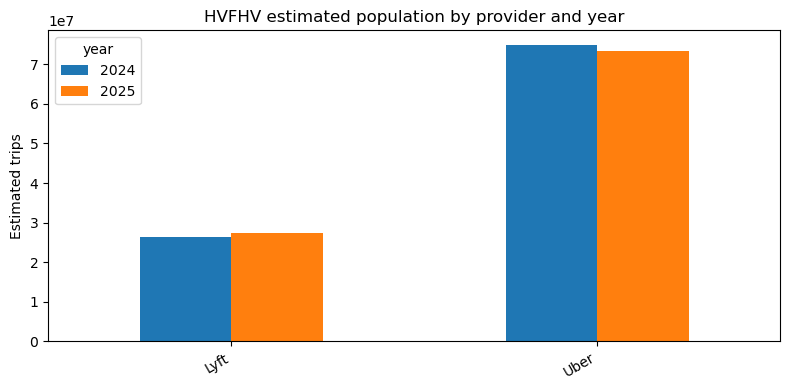

In [11]:
provider_by_year = (
    sample.groupby(["year", "provider_label"], dropna=False)
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "estimated_population": g["sample_weight"].sum(),
        "weighted_charged_share_pct": 100 * weighted_share(g["charged_cbd_flag"], g["sample_weight"]),
        "weighted_median_cost": weighted_quantile(g["passenger_cost_pretip"], g["sample_weight"], [0.5])[0],
        "weighted_median_driver_pay": weighted_quantile(g["driver_pay"], g["sample_weight"], [0.5])[0],
    }), include_groups=False)
    .reset_index()
)

display(provider_by_year)
save_table(provider_by_year, "hvfhv_provider_by_year.csv")

pivot = provider_by_year.pivot(index="provider_label", columns="year", values="estimated_population")
pivot.plot(kind="bar", figsize=(8, 4))
plt.title("HVFHV estimated population by provider and year")
plt.ylabel("Estimated trips")
plt.xlabel("")
plt.xticks(rotation=30, ha="right")
save_figure("hvfhv_provider_population_by_year.png")
plt.show()

## 5. Cost Component Reliability and Special Trip Regimes

This section mirrors the Yellow Taxi component-reliability check. For HVFHV, `passenger_cost_pretip` should be reconstructable from `base_passenger_fare`, `tolls`, `bcf`, `sales_tax`, `congestion_surcharge`, `airport_fee`, and `cbd_congestion_fee`.

In [12]:
cost_component_cols = [
    "base_passenger_fare",
    "tolls",
    "bcf",
    "sales_tax",
    "congestion_surcharge",
    "airport_fee",
    "cbd_congestion_fee",
]

component_values = sample[cost_component_cols]
sample["component_missing_flag"] = component_values.isna().any(axis=1)
sample["any_negative_available_component_flag"] = component_values.lt(0).any(axis=1)
sample["any_positive_available_component_flag"] = component_values.gt(0).any(axis=1)
sample["mixed_sign_available_component_flag"] = (
    sample["any_negative_available_component_flag"]
    & sample["any_positive_available_component_flag"]
)
sample["component_total"] = component_values.fillna(0).sum(axis=1)
sample["component_total_diff"] = (sample["passenger_cost_pretip"] - sample["component_total"]).round(2)
sample["component_total_match_flag"] = np.isclose(sample["component_total_diff"], 0, atol=0.01)

component_reliability_summary = (
    sample.groupby(["year", "provider_label"], dropna=False)
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "weighted_component_missing_pct": 100 * weighted_share(g["component_missing_flag"], g["sample_weight"]),
        "weighted_any_negative_component_pct": 100 * weighted_share(g["any_negative_available_component_flag"], g["sample_weight"]),
        "weighted_mixed_sign_component_pct": 100 * weighted_share(g["mixed_sign_available_component_flag"], g["sample_weight"]),
        "weighted_component_total_match_pct": 100 * weighted_share(g["component_total_match_flag"], g["sample_weight"]),
        "median_component_total_diff": g["component_total_diff"].median(),
    }), include_groups=False)
    .reset_index()
)

display(component_reliability_summary)
save_table(component_reliability_summary, "hvfhv_component_reliability_summary.csv")

,year,provider_label,sample_rows,weighted_component_missing_pct,weighted_any_negative_component_pct,weighted_mixed_sign_component_pct,weighted_component_total_match_pct,median_component_total_diff
0,2024,Lyft,"2,210.0000",0.0000,0.0000,0.0000,100.0000,0.0000
1,2024,Uber,"6,263.0000",0.0000,0.0160,0.0160,100.0000,0.0000
2,2025,Lyft,"2,283.0000",0.0000,0.0000,0.0000,100.0000,0.0000
3,2025,Uber,"6,133.0000",0.0000,0.0000,0.0000,100.0000,0.0000


,year,provider_label,sample_rows,weighted_component_missing_pct,weighted_any_negative_component_pct,weighted_mixed_sign_component_pct,weighted_component_total_match_pct,median_component_total_diff
0,2024,Lyft,"2,210.0000",0.0000,0.0000,0.0000,100.0000,0.0000
1,2024,Uber,"6,263.0000",0.0000,0.0160,0.0160,100.0000,0.0000
2,2025,Lyft,"2,283.0000",0.0000,0.0000,0.0000,100.0000,0.0000
3,2025,Uber,"6,133.0000",0.0000,0.0000,0.0000,100.0000,0.0000


In [13]:
negative_component_breakdown = []
for col in cost_component_cols + ["tips", "driver_pay", "passenger_cost_pretip"]:
    s = sample[col]
    negative_component_breakdown.append({
        "column": col,
        "negative_rows": int(s.lt(0).sum()),
        "zero_rows": int(s.eq(0).sum()),
        "positive_rows": int(s.gt(0).sum()),
        "missing_rows": int(s.isna().sum()),
        "weighted_negative_pct": 100 * weighted_share(s.lt(0), sample["sample_weight"]),
        "weighted_zero_pct": 100 * weighted_share(s.eq(0), sample["sample_weight"]),
    })

negative_component_breakdown = pd.DataFrame(negative_component_breakdown).sort_values(
    "weighted_negative_pct", ascending=False
)

display(negative_component_breakdown)
save_table(negative_component_breakdown, "hvfhv_monetary_sign_patterns.csv")

sample["component_total_diff"].value_counts().head(15).to_frame("sample_rows")

,column,negative_rows,zero_rows,positive_rows,missing_rows,weighted_negative_pct,weighted_zero_pct
0,base_passenger_fare,1,1,16887,0,0.0059,0.0059
1,tolls,0,14627,2262,0,0.0000,86.6067
2,bcf,0,40,16849,0,0.0000,0.2368
3,sales_tax,0,509,16380,0,0.0000,3.0138
4,congestion_surcharge,0,10367,6522,0,0.0000,61.3831
5,airport_fee,0,15474,1415,0,0.0000,91.6218
6,cbd_congestion_fee,0,13935,2954,0,0.0000,82.5100
7,tips,0,13614,3275,0,0.0000,80.6087
8,driver_pay,0,5,16884,0,0.0000,0.0296
9,passenger_cost_pretip,0,0,16889,0,0.0000,0.0000


,column,negative_rows,zero_rows,positive_rows,missing_rows,weighted_negative_pct,weighted_zero_pct
0,base_passenger_fare,1,1,16887,0,0.0059,0.0059
1,tolls,0,14627,2262,0,0.0000,86.6067
2,bcf,0,40,16849,0,0.0000,0.2368
3,sales_tax,0,509,16380,0,0.0000,3.0138
4,congestion_surcharge,0,10367,6522,0,0.0000,61.3831
5,airport_fee,0,15474,1415,0,0.0000,91.6218
6,cbd_congestion_fee,0,13935,2954,0,0.0000,82.5100
7,tips,0,13614,3275,0,0.0000,80.6087
8,driver_pay,0,5,16884,0,0.0000,0.0296
9,passenger_cost_pretip,0,0,16889,0,0.0000,0.0000


,sample_rows
component_total_diff,
0.0000,16889


## 6. CBD Congestion Fee and Relative Burden

This section checks the core policy variable: `cbd_congestion_fee`. For HVFHV passenger trips, the expected post-policy CBD charge is usually $1.50 when subject to the congestion pricing rule. Pre-policy 2024 rows should have CBD fee equal to zero.

In [14]:
cbd_value_counts = (
    sample.groupby(["year", "cbd_congestion_fee"], dropna=False)
    .agg(sample_rows=("sample_row_id", "count"), estimated_population=("sample_weight", "sum"))
    .reset_index()
    .sort_values(["year", "cbd_congestion_fee"])
)

display(cbd_value_counts)
save_table(cbd_value_counts, "hvfhv_cbd_fee_value_counts.csv")

,year,cbd_congestion_fee,sample_rows,estimated_population
0,2024,0.0000,8473,"101,192,388.0000"
1,2025,0.0000,5462,"65,226,905.3267"
2,2025,1.5000,2954,"35,276,556.6733"


,year,cbd_congestion_fee,sample_rows,estimated_population
0,2024,0.0000,8473,"101,192,388.0000"
1,2025,0.0000,5462,"65,226,905.3267"
2,2025,1.5000,2954,"35,276,556.6733"


,year,month,sample_rows,estimated_population,weighted_charged_cbd_share_pct,weighted_mean_cbd_fee,weighted_total_cbd_fee
0,2024,2,"1,620.0000","19,352,998.0000",0.0000,0.0000,0.0000
1,2024,3,"1,782.0000","21,279,860.0000",0.0000,0.0000,0.0000
2,2024,4,"1,652.0000","19,732,410.0000",0.0000,0.0000,0.0000
3,2024,5,"1,734.0000","20,704,206.0000",0.0000,0.0000,0.0000
4,2024,6,"1,685.0000","20,122,914.0000",0.0000,0.0000,0.0000
5,2025,2,"1,619.0000","19,338,054.0000",36.8128,0.5522,"10,678,332.4744"
6,2025,3,"1,715.0000","20,477,120.0000",35.6268,0.5344,"10,943,020.6880"
7,2025,4,"1,653.0000","19,741,018.0000",34.3618,0.5154,"10,175,043.7604"
8,2025,5,"1,766.0000","21,090,841.0000",33.8618,0.5079,"10,712,618.5600"
9,2025,6,"1,663.0000","19,856,429.0000",34.9369,0.5241,"10,405,819.5271"


,year,month,sample_rows,estimated_population,weighted_charged_cbd_share_pct,weighted_mean_cbd_fee,weighted_total_cbd_fee
0,2024,2,"1,620.0000","19,352,998.0000",0.0000,0.0000,0.0000
1,2024,3,"1,782.0000","21,279,860.0000",0.0000,0.0000,0.0000
2,2024,4,"1,652.0000","19,732,410.0000",0.0000,0.0000,0.0000
3,2024,5,"1,734.0000","20,704,206.0000",0.0000,0.0000,0.0000
4,2024,6,"1,685.0000","20,122,914.0000",0.0000,0.0000,0.0000
5,2025,2,"1,619.0000","19,338,054.0000",36.8128,0.5522,"10,678,332.4744"
6,2025,3,"1,715.0000","20,477,120.0000",35.6268,0.5344,"10,943,020.6880"
7,2025,4,"1,653.0000","19,741,018.0000",34.3618,0.5154,"10,175,043.7604"
8,2025,5,"1,766.0000","21,090,841.0000",33.8618,0.5079,"10,712,618.5600"
9,2025,6,"1,663.0000","19,856,429.0000",34.9369,0.5241,"10,405,819.5271"


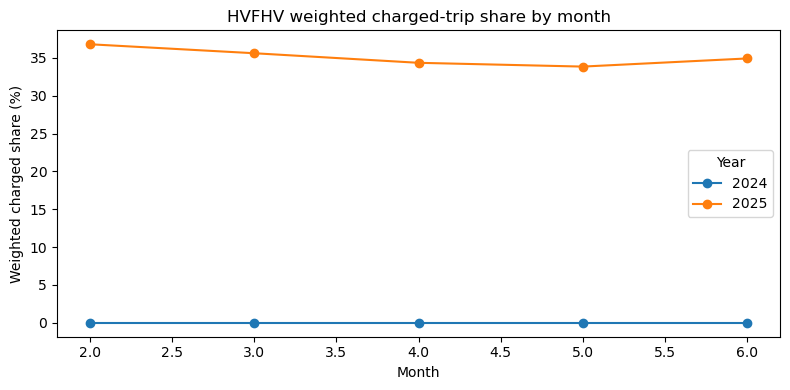

In [15]:
cbd_summary_by_month = (
    sample.groupby(["year", "month"], dropna=False)
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "estimated_population": g["sample_weight"].sum(),
        "weighted_charged_cbd_share_pct": 100 * weighted_share(g["charged_cbd_flag"], g["sample_weight"]),
        "weighted_mean_cbd_fee": weighted_mean(g["cbd_congestion_fee"], g["sample_weight"]),
        "weighted_total_cbd_fee": (g["cbd_congestion_fee"] * g["sample_weight"]).sum(),
    }), include_groups=False)
    .reset_index()
)

display(cbd_summary_by_month)
save_table(cbd_summary_by_month, "hvfhv_cbd_summary_by_month.csv")

fig, ax = plt.subplots(figsize=(8, 4))
for year, g in cbd_summary_by_month.groupby("year"):
    ax.plot(g["month"], g["weighted_charged_cbd_share_pct"], marker="o", label=str(year))
ax.set_title("HVFHV weighted charged-trip share by month")
ax.set_xlabel("Month")
ax.set_ylabel("Weighted charged share (%)")
ax.legend(title="Year")
save_figure("hvfhv_charged_share_by_month.png")
plt.show()

,definition,sample_rows,weighted_mean,weighted_median,weighted_p95
0,fee/current cost,2954,0.0470,0.0423,0.0955
1,fee/base cost excluding CBD,2954,0.0501,0.0442,0.1056


,definition,sample_rows,weighted_mean,weighted_median,weighted_p95
0,fee/current cost,2954,0.0470,0.0423,0.0955
1,fee/base cost excluding CBD,2954,0.0501,0.0442,0.1056


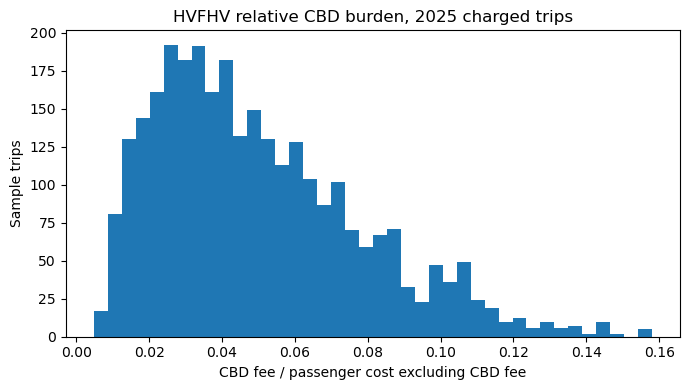

In [16]:
charged_2025 = sample[sample["post_policy_charged_cbd_flag"]].copy()

burden_summary = pd.DataFrame({
    "definition": ["fee/current cost", "fee/base cost excluding CBD"],
    "sample_rows": [len(charged_2025), len(charged_2025)],
    "weighted_mean": [
        weighted_mean(charged_2025["relative_cbd_burden_current_cost"], charged_2025["sample_weight"]),
        weighted_mean(charged_2025["relative_cbd_burden_base_cost"], charged_2025["sample_weight"]),
    ],
    "weighted_median": [
        weighted_quantile(charged_2025["relative_cbd_burden_current_cost"], charged_2025["sample_weight"], [0.5])[0],
        weighted_quantile(charged_2025["relative_cbd_burden_base_cost"], charged_2025["sample_weight"], [0.5])[0],
    ],
    "weighted_p95": [
        weighted_quantile(charged_2025["relative_cbd_burden_current_cost"], charged_2025["sample_weight"], [0.95])[0],
        weighted_quantile(charged_2025["relative_cbd_burden_base_cost"], charged_2025["sample_weight"], [0.95])[0],
    ],
})

display(burden_summary)
save_table(burden_summary, "hvfhv_burden_definition_summary.csv")

plot_df = charged_2025[
    charged_2025["relative_cbd_burden_base_cost"].between(0, 0.30)
].copy()
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(plot_df["relative_cbd_burden_base_cost"], bins=40)
ax.set_title("HVFHV relative CBD burden, 2025 charged trips")
ax.set_xlabel("CBD fee / passenger cost excluding CBD fee")
ax.set_ylabel("Sample trips")
save_figure("hvfhv_relative_cbd_burden_distribution.png")
plt.show()

In [17]:
# Low-denominator sensitivity mirrors the Yellow Taxi burden caution.
floors = [0.50, 1.00, 2.00, 5.00]
floor_rows = []
for floor in floors:
    retained = charged_2025[charged_2025["base_cost_ex_cbd"].ge(floor)].copy()
    floor_rows.append({
        "minimum_base_cost": floor,
        "sample_n_total_charged": len(charged_2025),
        "sample_n_retained": len(retained),
        "sample_retained_share_pct": 100 * len(retained) / len(charged_2025) if len(charged_2025) else np.nan,
        "weighted_retained_share_pct": 100 * retained["sample_weight"].sum() / charged_2025["sample_weight"].sum() if len(charged_2025) else np.nan,
        "weighted_median_burden": weighted_quantile(
            retained["relative_cbd_burden_base_cost"], retained["sample_weight"], [0.5]
        )[0],
        "weighted_p95_burden": weighted_quantile(
            retained["relative_cbd_burden_base_cost"], retained["sample_weight"], [0.95]
        )[0],
    })

floor_sensitivity = pd.DataFrame(floor_rows)
display(floor_sensitivity)
save_table(floor_sensitivity, "hvfhv_floor_sensitivity.csv")

,minimum_base_cost,sample_n_total_charged,sample_n_retained,sample_retained_share_pct,weighted_retained_share_pct,weighted_median_burden,weighted_p95_burden
0,0.5000,2954,2954,100.0000,100.0000,0.0442,0.1056
1,1.0000,2954,2954,100.0000,100.0000,0.0442,0.1056
2,2.0000,2954,2954,100.0000,100.0000,0.0442,0.1056
3,5.0000,2954,2954,100.0000,100.0000,0.0442,0.1056


,minimum_base_cost,sample_n_total_charged,sample_n_retained,sample_retained_share_pct,weighted_retained_share_pct,weighted_median_burden,weighted_p95_burden
0,0.5000,2954,2954,100.0000,100.0000,0.0442,0.1056
1,1.0000,2954,2954,100.0000,100.0000,0.0442,0.1056
2,2.0000,2954,2954,100.0000,100.0000,0.0442,0.1056
3,5.0000,2954,2954,100.0000,100.0000,0.0442,0.1056


## 7. Passenger Cost, Trip Distance, Trip Duration, and Driver Pay

This section checks the main trip-level variables that may be used as outcomes, controls, or denominators. Unlike CBD burden, these variables exist in both 2024 and 2025, but they should still be summarized by month rather than collapsed into one overall pre/post average.

In [18]:
core_vars = [
    "passenger_cost_pretip",
    "trip_distance_miles",
    "trip_duration_seconds",
    "driver_pay",
    "gross_cost_per_mile",
    "driver_pay_per_mile",
    "driver_pay_per_hour",
]

summary_parts = []
for col in core_vars:
    temp = weighted_summary(sample[sample["main_analysis_flag"]], col, ["year", "month"])
    temp.insert(0, "variable", col)
    summary_parts.append(temp)

core_summary = pd.concat(summary_parts, ignore_index=True)
display(core_summary)
save_table(core_summary, "hvfhv_continuous_summary_by_month.csv")

,variable,group,weighted_mean,weighted_p25,weighted_median,weighted_p75,unweighted_n,estimated_population
0,passenger_cost_pretip,"(2024, 2)",28.8470,13.9600,21.6350,34.9650,1620,"19,352,998.0000"
1,passenger_cost_pretip,"(2024, 3)",32.1199,14.6800,23.0100,38.9900,1782,"21,279,860.0000"
2,passenger_cost_pretip,"(2024, 4)",31.6924,14.6150,22.8850,38.7150,1652,"19,732,410.0000"
3,passenger_cost_pretip,"(2024, 5)",31.1016,14.8700,23.0500,37.0100,1734,"20,704,206.0000"
4,passenger_cost_pretip,"(2024, 6)",33.0851,14.9800,23.6500,38.8850,1685,"20,122,914.0000"
...,...,...,...,...,...,...,...,...
65,driver_pay_per_hour,"(2025, 2)",60.2570,48.7687,55.3580,65.9045,1619,"19,338,054.0000"
66,driver_pay_per_hour,"(2025, 3)",63.5800,50.9811,57.0503,68.7196,1715,"20,477,120.0000"
67,driver_pay_per_hour,"(2025, 4)",61.2809,50.3955,56.5063,66.9105,1653,"19,741,018.0000"
68,driver_pay_per_hour,"(2025, 5)",62.1138,50.3636,55.9442,67.2090,1766,"21,090,841.0000"


,variable,group,weighted_mean,weighted_p25,weighted_median,weighted_p75,unweighted_n,estimated_population
0,passenger_cost_pretip,"(2024, 2)",28.8470,13.9600,21.6350,34.9650,1620,"19,352,998.0000"
1,passenger_cost_pretip,"(2024, 3)",32.1199,14.6800,23.0100,38.9900,1782,"21,279,860.0000"
2,passenger_cost_pretip,"(2024, 4)",31.6924,14.6150,22.8850,38.7150,1652,"19,732,410.0000"
3,passenger_cost_pretip,"(2024, 5)",31.1016,14.8700,23.0500,37.0100,1734,"20,704,206.0000"
4,passenger_cost_pretip,"(2024, 6)",33.0851,14.9800,23.6500,38.8850,1685,"20,122,914.0000"
...,...,...,...,...,...,...,...,...
65,driver_pay_per_hour,"(2025, 2)",60.2570,48.7687,55.3580,65.9045,1619,"19,338,054.0000"
66,driver_pay_per_hour,"(2025, 3)",63.5800,50.9811,57.0503,68.7196,1715,"20,477,120.0000"
67,driver_pay_per_hour,"(2025, 4)",61.2809,50.3955,56.5063,66.9105,1653,"19,741,018.0000"
68,driver_pay_per_hour,"(2025, 5)",62.1138,50.3636,55.9442,67.2090,1766,"21,090,841.0000"


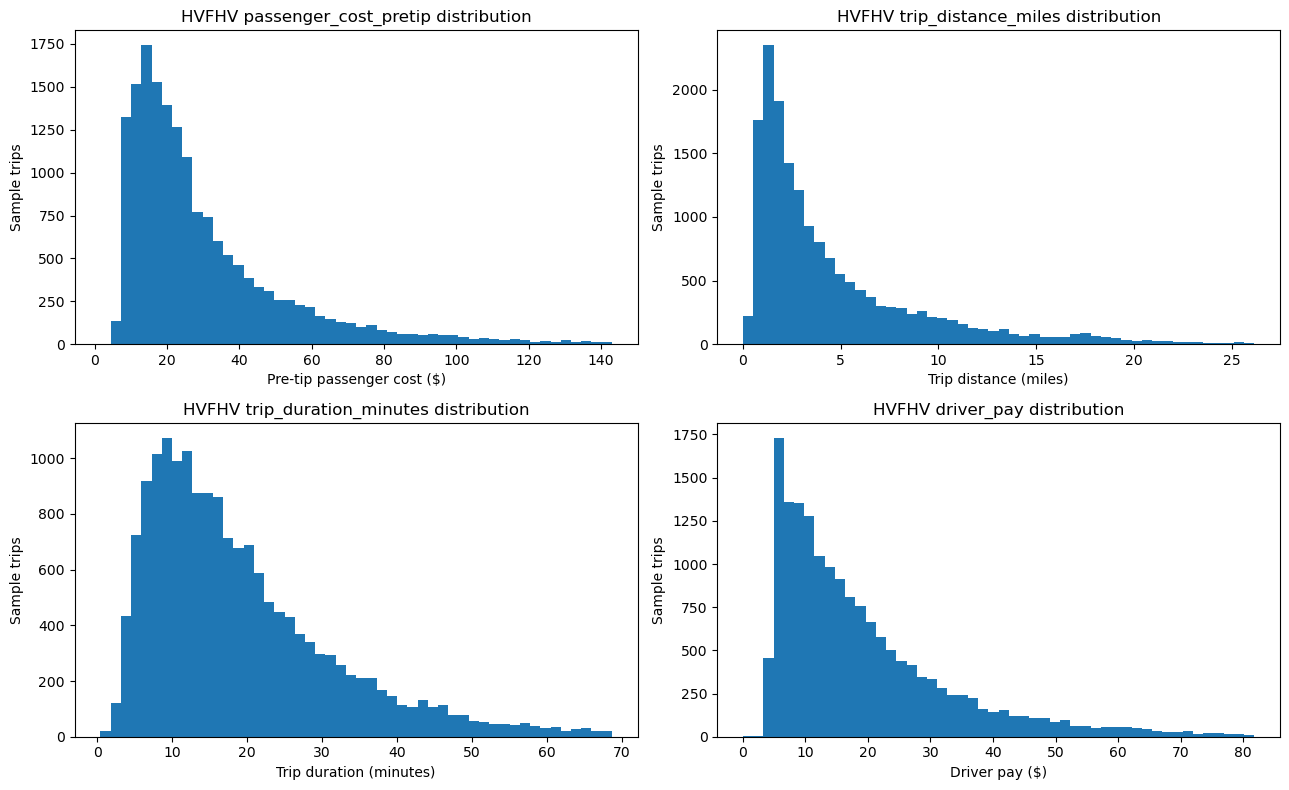

In [19]:
plot_specs = [
    ("passenger_cost_pretip", "Pre-tip passenger cost ($)", 0.99),
    ("trip_distance_miles", "Trip distance (miles)", 0.99),
    ("trip_duration_minutes", "Trip duration (minutes)", 0.99),
    ("driver_pay", "Driver pay ($)", 0.99),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (col, xlabel, qmax) in zip(axes.ravel(), plot_specs):
    upper = sample[col].quantile(qmax)
    plot_data = sample.loc[sample[col].between(0, upper), col].dropna()
    ax.hist(plot_data, bins=50)
    ax.set_title(f"HVFHV {col} distribution")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Sample trips")
save_figure("hvfhv_core_distribution_panel.png")
plt.show()

## 8. Time Patterns

This section checks whether CBD charging and trip volume patterns vary by pickup hour and day of week. This is descriptive, not causal; the purpose is to guide later feature engineering.

,year,pickup_hour,sample_rows,estimated_population,weighted_charged_cbd_share_pct,weighted_median_cost,weighted_median_driver_pay
0,2024,0,328.0000,"3,917,190.3019",0.0000,22.4900,15.3299
1,2024,1,206.0000,"2,460,224.8905",0.0000,21.9150,13.2750
2,2024,2,139.0000,"1,660,065.2673",0.0000,21.1996,14.0295
3,2024,3,120.0000,"1,433,144.3455",0.0000,23.8349,15.0250
4,2024,4,115.0000,"1,373,443.4931",0.0000,27.8593,17.8399


,year,pickup_hour,sample_rows,estimated_population,weighted_charged_cbd_share_pct,weighted_median_cost,weighted_median_driver_pay
0,2024,0,328.0000,"3,917,190.3019",0.0000,22.4900,15.3299
1,2024,1,206.0000,"2,460,224.8905",0.0000,21.9150,13.2750
2,2024,2,139.0000,"1,660,065.2673",0.0000,21.1996,14.0295
3,2024,3,120.0000,"1,433,144.3455",0.0000,23.8349,15.0250
4,2024,4,115.0000,"1,373,443.4931",0.0000,27.8593,17.8399
5,2024,5,170.0000,"2,030,288.5630",0.0000,24.2552,16.2051
6,2024,6,235.0000,"2,806,552.0192",0.0000,22.8999,14.7098
7,2024,7,378.0000,"4,514,436.3294",0.0000,24.8698,16.5849
8,2024,8,443.0000,"5,290,743.0517",0.0000,21.9098,15.1500
9,2024,9,434.0000,"5,183,213.1191",0.0000,20.9850,12.7699


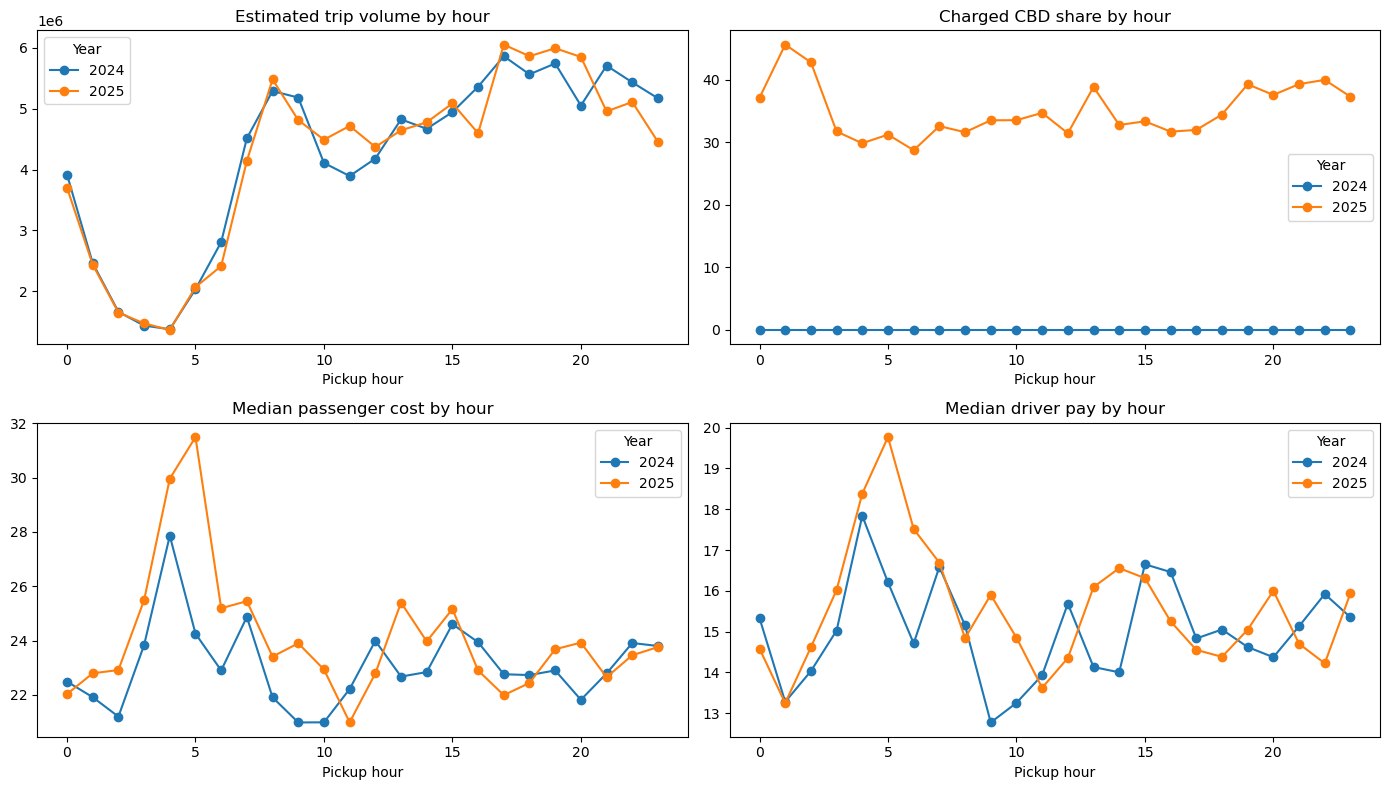

In [20]:
hourly = (
    sample.groupby(["year", "pickup_hour"], dropna=False)
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "estimated_population": g["sample_weight"].sum(),
        "weighted_charged_cbd_share_pct": 100 * weighted_share(g["charged_cbd_flag"], g["sample_weight"]),
        "weighted_median_cost": weighted_quantile(g["passenger_cost_pretip"], g["sample_weight"], [0.5])[0],
        "weighted_median_driver_pay": weighted_quantile(g["driver_pay"], g["sample_weight"], [0.5])[0],
    }), include_groups=False)
    .reset_index()
    .sort_values(["year", "pickup_hour"])
)

display(hourly.head())
save_table(hourly, "hvfhv_hourly_patterns.csv")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for year, g in hourly.groupby("year"):
    axes[0, 0].plot(g["pickup_hour"], g["estimated_population"], marker="o", label=str(year))
    axes[0, 1].plot(g["pickup_hour"], g["weighted_charged_cbd_share_pct"], marker="o", label=str(year))
    axes[1, 0].plot(g["pickup_hour"], g["weighted_median_cost"], marker="o", label=str(year))
    axes[1, 1].plot(g["pickup_hour"], g["weighted_median_driver_pay"], marker="o", label=str(year))
axes[0, 0].set_title("Estimated trip volume by hour")
axes[0, 1].set_title("Charged CBD share by hour")
axes[1, 0].set_title("Median passenger cost by hour")
axes[1, 1].set_title("Median driver pay by hour")
for ax in axes.ravel():
    ax.set_xlabel("Pickup hour")
    ax.legend(title="Year")
save_figure("hvfhv_hourly_patterns_panel.png")
plt.show()

In [21]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_summary = (
    sample.groupby(["year", "pickup_weekday"], dropna=False)
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "estimated_population": g["sample_weight"].sum(),
        "weighted_charged_cbd_share_pct": 100 * weighted_share(g["charged_cbd_flag"], g["sample_weight"]),
        "weighted_median_cost": weighted_quantile(g["passenger_cost_pretip"], g["sample_weight"], [0.5])[0],
    }), include_groups=False)
    .reset_index()
)

dow_summary["pickup_weekday"] = pd.Categorical(
    dow_summary["pickup_weekday"], categories=weekday_order, ordered=True
)
dow_summary = dow_summary.sort_values(["year", "pickup_weekday"])

display(dow_summary)
save_table(dow_summary, "hvfhv_weekday_patterns.csv")

,year,pickup_weekday,sample_rows,estimated_population,weighted_charged_cbd_share_pct,weighted_median_cost
1,2024,Monday,948.0000,"11,321,920.9043",0.0000,20.9800
5,2024,Tuesday,"1,019.0000","12,170,062.8093",0.0000,22.6400
6,2024,Wednesday,"1,149.0000","13,722,231.1832",0.0000,24.0400
4,2024,Thursday,"1,264.0000","15,096,101.8609",0.0000,23.9850
0,2024,Friday,"1,389.0000","16,588,542.7607",0.0000,22.6500
2,2024,Saturday,"1,487.0000","17,758,993.6688",0.0000,22.3794
3,2024,Sunday,"1,217.0000","14,534,534.8127",0.0000,23.7390
8,2025,Monday,"1,076.0000","12,849,287.2473",34.2936,23.5450
12,2025,Tuesday,"1,054.0000","12,586,867.2440",34.8201,22.6950
13,2025,Wednesday,"1,174.0000","14,019,951.8460",37.3933,23.9900


,year,pickup_weekday,sample_rows,estimated_population,weighted_charged_cbd_share_pct,weighted_median_cost
1,2024,Monday,948.0000,"11,321,920.9043",0.0000,20.9800
5,2024,Tuesday,"1,019.0000","12,170,062.8093",0.0000,22.6400
6,2024,Wednesday,"1,149.0000","13,722,231.1832",0.0000,24.0400
4,2024,Thursday,"1,264.0000","15,096,101.8609",0.0000,23.9850
0,2024,Friday,"1,389.0000","16,588,542.7607",0.0000,22.6500
2,2024,Saturday,"1,487.0000","17,758,993.6688",0.0000,22.3794
3,2024,Sunday,"1,217.0000","14,534,534.8127",0.0000,23.7390
8,2025,Monday,"1,076.0000","12,849,287.2473",34.2936,23.5450
12,2025,Tuesday,"1,054.0000","12,586,867.2440",34.8201,22.6950
13,2025,Wednesday,"1,174.0000","14,019,951.8460",37.3933,23.9900


## 9. Zone-Level First Look

This section gives a descriptive look at pickup and dropoff zones. TLC zone IDs are categorical labels, so final zone-level rankings should use full-data aggregates and the zone lookup table.

In [22]:
zone_lookup = pd.read_csv(ZONE_LOOKUP_PATH)[["LocationID", "Borough", "Zone"]]

def zone_summary_for(data, zone_col, direction):
    rows = []
    subset = data[data["year"].eq(2025)].copy()
    for zone, g in subset.groupby(zone_col, dropna=False):
        charged = g[g["charged_cbd_flag"]]
        rows.append({
            "direction": direction,
            "LocationID": zone,
            "sample_rows": len(g),
            "estimated_population": g["sample_weight"].sum(),
            "weighted_charged_cbd_share_pct": 100 * weighted_share(g["charged_cbd_flag"], g["sample_weight"]),
            "conditional_weighted_median_burden": weighted_quantile(
                charged["relative_cbd_burden_base_cost"], charged["sample_weight"], [0.5]
            )[0] if len(charged) else np.nan,
            "weighted_total_cbd_fee": (charged["cbd_congestion_fee"] * charged["sample_weight"]).sum(),
        })
    out = pd.DataFrame(rows)
    return out.merge(zone_lookup, how="left", on="LocationID")

pickup_zone_summary = zone_summary_for(sample, "PULocationID", "pickup")
dropoff_zone_summary = zone_summary_for(sample, "DOLocationID", "dropoff")
zone_summary = pd.concat([pickup_zone_summary, dropoff_zone_summary], ignore_index=True)

display(zone_summary.head())
save_table(zone_summary, "hvfhv_zone_summary_2025.csv")

,direction,LocationID,sample_rows,estimated_population,weighted_charged_cbd_share_pct,conditional_weighted_median_burden,weighted_total_cbd_fee,Borough,Zone
0,pickup,3,17,"203,009.2316",0.0000,NaN,0.0000,Bronx,Allerton/Pelham Gardens
1,pickup,4,31,"370,189.8351",96.7746,0.0572,"537,374.7352",Manhattan,Alphabet City
2,pickup,5,2,"23,882.8442",0.0000,NaN,0.0000,Staten Island,Arden Heights
3,pickup,6,5,"59,700.4004",19.9999,0.0273,"17,910.0175",Staten Island,Arrochar/Fort Wadsworth
4,pickup,7,67,"800,131.9397",11.9402,0.0496,"143,305.5191",Queens,Astoria


,direction,LocationID,sample_rows,estimated_population,weighted_charged_cbd_share_pct,conditional_weighted_median_burden,weighted_total_cbd_fee,Borough,Zone
0,pickup,3,17,"203,009.2316",0.0000,NaN,0.0000,Bronx,Allerton/Pelham Gardens
1,pickup,4,31,"370,189.8351",96.7746,0.0572,"537,374.7352",Manhattan,Alphabet City
2,pickup,5,2,"23,882.8442",0.0000,NaN,0.0000,Staten Island,Arden Heights
3,pickup,6,5,"59,700.4004",19.9999,0.0273,"17,910.0175",Staten Island,Arrochar/Fort Wadsworth
4,pickup,7,67,"800,131.9397",11.9402,0.0496,"143,305.5191",Queens,Astoria
...,...,...,...,...,...,...,...,...,...
494,dropoff,260,33,"394,094.6645",6.0595,0.0542,"35,820.0350",Queens,Woodside
495,dropoff,261,28,"334,375.7829",100.0000,0.0516,"501,563.6743",Manhattan,World Trade Center
496,dropoff,262,27,"322,427.9005",40.7424,0.0502,"197,047.3869",Manhattan,Yorkville East
497,dropoff,263,36,"429,931.9010",36.1106,0.0527,"232,876.4859",Manhattan,Yorkville West


In [23]:
rankable_zones = zone_summary[
    zone_summary["sample_rows"].ge(30)
    & zone_summary["conditional_weighted_median_burden"].notna()
].copy()

display(
    rankable_zones.sort_values("conditional_weighted_median_burden", ascending=False)[
        [
            "direction",
            "LocationID",
            "Borough",
            "Zone",
            "sample_rows",
            "weighted_charged_cbd_share_pct",
            "conditional_weighted_median_burden",
            "weighted_total_cbd_fee",
        ]
    ].head(20)
)

,direction,LocationID,Borough,Zone,sample_rows,weighted_charged_cbd_share_pct,conditional_weighted_median_burden,weighted_total_cbd_fee
464,dropoff,229,Manhattan,Sutton Place/Turtle Bay North,32,100.0000,0.0631,"573,214.4452"
169,pickup,186,Manhattan,Penn Station/Madison Sq West,46,100.0000,0.0627,"823,988.1826"
484,dropoff,249,Manhattan,West Village,77,98.7012,0.0627,"1,361,407.7345"
122,pickup,137,Manhattan,Kips Bay,37,100.0000,0.0625,"662,784.4020"
378,dropoff,141,Manhattan,Lenox Hill West,47,48.9355,0.0624,"411,992.9757"
83,pickup,90,Manhattan,Flatiron,59,98.3047,0.0623,"1,038,940.2484"
346,dropoff,107,Manhattan,Gramercy,56,98.2146,0.0617,"985,216.3707"
468,dropoff,233,Manhattan,UN/Turtle Bay South,43,100.0000,0.0614,"770,258.3086"
374,dropoff,137,Manhattan,Kips Bay,40,100.0000,0.0613,"716,518.7025"
95,pickup,107,Manhattan,Gramercy,63,100.0000,0.0610,"1,128,501.4668"


## 10. Relationship Between Variables

The goal here is to identify which variables are redundant and which can serve as independent controls. Mechanically derived variables are interpreted cautiously because they are definitionally related.

,trip_distance_miles,trip_duration_minutes,passenger_cost_pretip,base_passenger_fare,tolls,airport_fee,driver_pay,gross_cost_per_mile,driver_pay_per_mile,speed_mph
trip_distance_miles,1.0000,0.7995,0.8617,0.8638,0.5414,0.4392,0.9229,-0.1672,-0.2006,0.7194
trip_duration_minutes,0.7995,1.0000,0.8159,0.8169,0.4397,0.3691,0.9068,-0.1405,-0.1343,0.3181
passenger_cost_pretip,0.8617,0.8159,1.0000,0.9924,0.5920,0.4815,0.9311,-0.0517,-0.0951,0.5085
base_passenger_fare,0.8638,0.8169,0.9924,1.0000,0.5173,0.4586,0.9359,-0.0574,-0.0944,0.5001
tolls,0.5414,0.4397,0.5920,0.5173,1.0000,0.2730,0.5249,-0.0546,-0.0910,0.3901
airport_fee,0.4392,0.3691,0.4815,0.4586,0.2730,1.0000,0.4216,-0.0575,-0.0952,0.3885
driver_pay,0.9229,0.9068,0.9311,0.9359,0.5249,0.4216,1.0000,-0.1127,-0.1065,0.5247
gross_cost_per_mile,-0.1672,-0.1405,-0.0517,-0.0574,-0.0546,-0.0575,-0.1127,1.0000,0.8246,-0.2294
driver_pay_per_mile,-0.2006,-0.1343,-0.0951,-0.0944,-0.0910,-0.0952,-0.1065,0.8246,1.0000,-0.2998
speed_mph,0.7194,0.3181,0.5085,0.5001,0.3901,0.3885,0.5247,-0.2294,-0.2998,1.0000


,variable,trip_distance_miles,trip_duration_minutes,passenger_cost_pretip,base_passenger_fare,tolls,airport_fee,driver_pay,gross_cost_per_mile,driver_pay_per_mile,speed_mph
0,trip_distance_miles,1.0000,0.7995,0.8617,0.8638,0.5414,0.4392,0.9229,-0.1672,-0.2006,0.7194
1,trip_duration_minutes,0.7995,1.0000,0.8159,0.8169,0.4397,0.3691,0.9068,-0.1405,-0.1343,0.3181
2,passenger_cost_pretip,0.8617,0.8159,1.0000,0.9924,0.5920,0.4815,0.9311,-0.0517,-0.0951,0.5085
3,base_passenger_fare,0.8638,0.8169,0.9924,1.0000,0.5173,0.4586,0.9359,-0.0574,-0.0944,0.5001
4,tolls,0.5414,0.4397,0.5920,0.5173,1.0000,0.2730,0.5249,-0.0546,-0.0910,0.3901
5,airport_fee,0.4392,0.3691,0.4815,0.4586,0.2730,1.0000,0.4216,-0.0575,-0.0952,0.3885
6,driver_pay,0.9229,0.9068,0.9311,0.9359,0.5249,0.4216,1.0000,-0.1127,-0.1065,0.5247
7,gross_cost_per_mile,-0.1672,-0.1405,-0.0517,-0.0574,-0.0546,-0.0575,-0.1127,1.0000,0.8246,-0.2294
8,driver_pay_per_mile,-0.2006,-0.1343,-0.0951,-0.0944,-0.0910,-0.0952,-0.1065,0.8246,1.0000,-0.2998
9,speed_mph,0.7194,0.3181,0.5085,0.5001,0.3901,0.3885,0.5247,-0.2294,-0.2998,1.0000


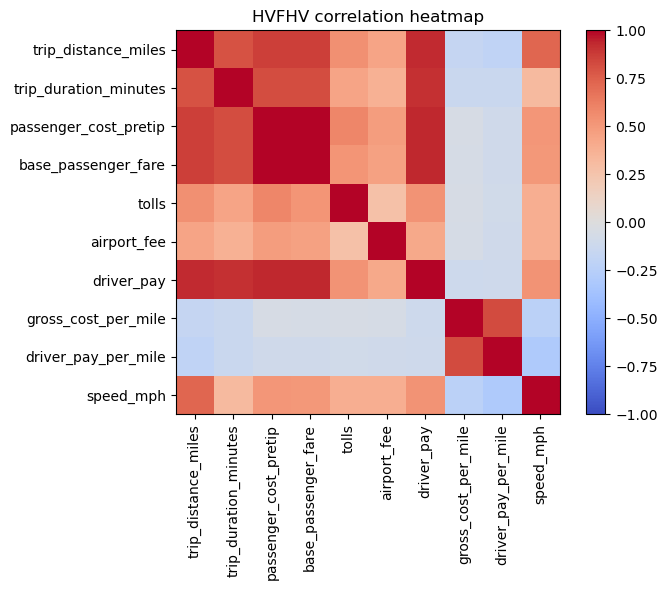

In [24]:
relationship_cols = [
    "trip_distance_miles",
    "trip_duration_minutes",
    "passenger_cost_pretip",
    "base_passenger_fare",
    "tolls",
    "airport_fee",
    "driver_pay",
    "gross_cost_per_mile",
    "driver_pay_per_mile",
    "speed_mph",
]

corr_df = sample.loc[sample["main_analysis_flag"], relationship_cols].replace([np.inf, -np.inf], np.nan).dropna()
corr = corr_df.corr()

display(corr)
save_table(corr.reset_index(names="variable"), "hvfhv_correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title("HVFHV correlation heatmap")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
save_figure("hvfhv_correlation_heatmap.png")
plt.show()

In [25]:
provider_relation = (
    sample[sample["main_analysis_flag"]]
    .groupby(["year", "provider_label"], dropna=False)
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "weighted_median_distance": weighted_quantile(g["trip_distance_miles"], g["sample_weight"], [0.5])[0],
        "weighted_median_cost": weighted_quantile(g["passenger_cost_pretip"], g["sample_weight"], [0.5])[0],
        "weighted_median_driver_pay": weighted_quantile(g["driver_pay"], g["sample_weight"], [0.5])[0],
        "weighted_shared_request_pct": 100 * weighted_share(g["shared_request_yes_flag"], g["sample_weight"]),
    }), include_groups=False)
    .reset_index()
)

display(provider_relation)
save_table(provider_relation, "hvfhv_provider_relationship_summary.csv")

,year,provider_label,sample_rows,weighted_median_distance,weighted_median_cost,weighted_median_driver_pay,weighted_shared_request_pct
0,2024,Lyft,"2,210.0000",3.0390,23.8900,15.0700,0.0000
1,2024,Uber,"6,263.0000",2.9600,22.6600,14.9700,4.7263
2,2025,Lyft,"2,283.0000",2.9090,22.5896,14.8899,0.0000
3,2025,Uber,"6,133.0000",2.9100,23.9700,15.3699,4.0600


,year,provider_label,sample_rows,weighted_median_distance,weighted_median_cost,weighted_median_driver_pay,weighted_shared_request_pct
0,2024,Lyft,"2,210.0000",3.0390,23.8900,15.0700,0.0000
1,2024,Uber,"6,263.0000",2.9600,22.6600,14.9700,4.7263
2,2025,Lyft,"2,283.0000",2.9090,22.5896,14.8899,0.0000
3,2025,Uber,"6,133.0000",2.9100,23.9700,15.3699,4.0600


## 11. Pre/Post Comparability

Because the project compares pre-policy 2024 trips to post-policy 2025 trips, we need to check whether the two periods have similar trip composition. If composition differs, raw before/after averages can be misleading.

In [26]:
monthly_comparability = (
    sample.groupby(["year", "month"], dropna=False)
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "estimated_population": g["sample_weight"].sum(),
        "weighted_median_cost": weighted_quantile(g["passenger_cost_pretip"], g["sample_weight"], [0.5])[0],
        "weighted_median_distance": weighted_quantile(g["trip_distance_miles"], g["sample_weight"], [0.5])[0],
        "weighted_median_duration_minutes": weighted_quantile(g["trip_duration_minutes"], g["sample_weight"], [0.5])[0],
        "weighted_median_driver_pay": weighted_quantile(g["driver_pay"], g["sample_weight"], [0.5])[0],
        "weighted_shared_request_pct": 100 * weighted_share(g["shared_request_yes_flag"], g["sample_weight"]),
        "weighted_charged_cbd_share_pct": 100 * weighted_share(g["charged_cbd_flag"], g["sample_weight"]),
    }), include_groups=False)
    .reset_index()
)

display(monthly_comparability)
save_table(monthly_comparability, "hvfhv_monthly_comparability.csv")

,year,month,sample_rows,estimated_population,weighted_median_cost,weighted_median_distance,weighted_median_duration_minutes,weighted_median_driver_pay,weighted_shared_request_pct,weighted_charged_cbd_share_pct
0,2024,2,"1,620.0000","19,352,998.0000",21.6350,2.8940,15.5250,14.2500,4.6914,0.0000
1,2024,3,"1,782.0000","21,279,860.0000",23.0100,3.0400,16.1917,15.1650,3.2548,0.0000
2,2024,4,"1,652.0000","19,732,410.0000",22.8850,2.9900,16.4500,14.9550,3.3293,0.0000
3,2024,5,"1,734.0000","20,704,206.0000",23.0500,2.9300,16.4583,15.1550,3.5755,0.0000
4,2024,6,"1,685.0000","20,122,914.0000",23.6500,3.0400,16.7000,15.3400,2.6706,0.0000
5,2025,2,"1,619.0000","19,338,054.0000",23.0200,2.8600,15.4833,14.3800,3.5207,36.8128
6,2025,3,"1,715.0000","20,477,120.0000",24.2200,2.8200,15.4167,15.0600,2.9155,35.6268
7,2025,4,"1,653.0000","19,741,018.0000",22.1300,2.9700,15.9000,15.0500,2.7828,34.3618
8,2025,5,"1,766.0000","21,090,841.0000",23.9250,2.8765,16.0083,15.5450,2.8313,33.8618
9,2025,6,"1,663.0000","19,856,429.0000",23.9900,3.0000,16.1500,16.1900,2.7661,34.9369


,year,month,sample_rows,estimated_population,weighted_median_cost,weighted_median_distance,weighted_median_duration_minutes,weighted_median_driver_pay,weighted_shared_request_pct,weighted_charged_cbd_share_pct
0,2024,2,"1,620.0000","19,352,998.0000",21.6350,2.8940,15.5250,14.2500,4.6914,0.0000
1,2024,3,"1,782.0000","21,279,860.0000",23.0100,3.0400,16.1917,15.1650,3.2548,0.0000
2,2024,4,"1,652.0000","19,732,410.0000",22.8850,2.9900,16.4500,14.9550,3.3293,0.0000
3,2024,5,"1,734.0000","20,704,206.0000",23.0500,2.9300,16.4583,15.1550,3.5755,0.0000
4,2024,6,"1,685.0000","20,122,914.0000",23.6500,3.0400,16.7000,15.3400,2.6706,0.0000
5,2025,2,"1,619.0000","19,338,054.0000",23.0200,2.8600,15.4833,14.3800,3.5207,36.8128
6,2025,3,"1,715.0000","20,477,120.0000",24.2200,2.8200,15.4167,15.0600,2.9155,35.6268
7,2025,4,"1,653.0000","19,741,018.0000",22.1300,2.9700,15.9000,15.0500,2.7828,34.3618
8,2025,5,"1,766.0000","21,090,841.0000",23.9250,2.8765,16.0083,15.5450,2.8313,33.8618
9,2025,6,"1,663.0000","19,856,429.0000",23.9900,3.0000,16.1500,16.1900,2.7661,34.9369


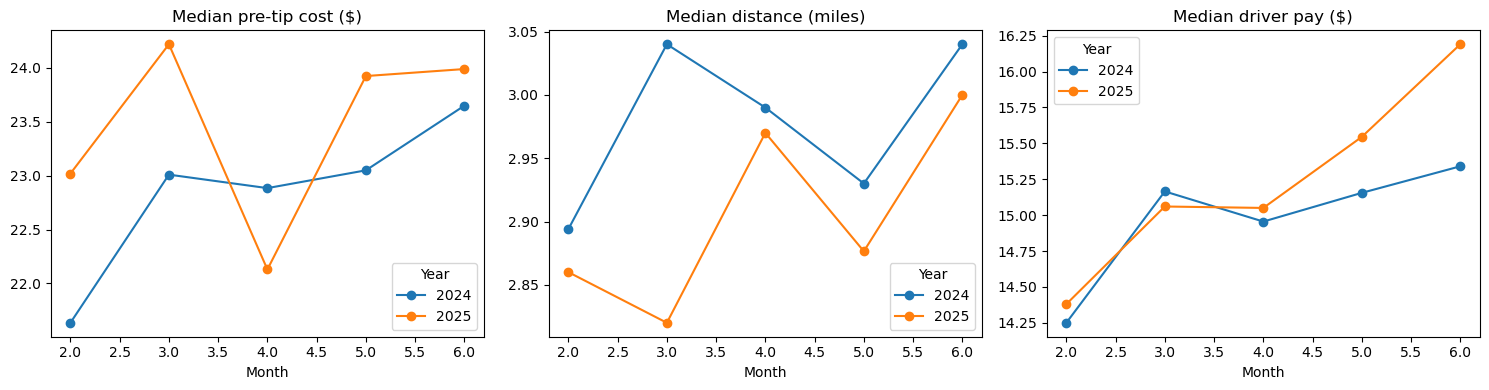

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [
    ("weighted_median_cost", "Median pre-tip cost ($)"),
    ("weighted_median_distance", "Median distance (miles)"),
    ("weighted_median_driver_pay", "Median driver pay ($)"),
]
for ax, (col, title) in zip(axes, metrics):
    for year, g in monthly_comparability.groupby("year"):
        ax.plot(g["month"], g[col], marker="o", label=str(year))
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.legend(title="Year")
save_figure("hvfhv_pre_post_monthly_comparability.png")
plt.show()

## 12. CBD Exposure and Geography

This section explores which trips are more likely to be charged the CBD fee. It is descriptive, not causal. The purpose is to identify geography, time, and trip-length features that may be useful later.

,pickup_hour,sample_rows,estimated_population,charged_cbd_share_pct,median_relative_burden_charged_pct
0,0,310.0000,"3,701,985.5331",37.0967,4.1164
1,1,204.0000,"2,436,140.5245",45.5885,5.2761
2,2,138.0000,"1,647,958.0726",42.7542,5.0813
3,3,123.0000,"1,468,861.2226",31.7080,4.2481
4,4,114.0000,"1,361,387.6639",29.8256,2.5437


,pickup_hour,sample_rows,estimated_population,charged_cbd_share_pct,median_relative_burden_charged_pct
0,0,310.0000,"3,701,985.5331",37.0967,4.1164
1,1,204.0000,"2,436,140.5245",45.5885,5.2761
2,2,138.0000,"1,647,958.0726",42.7542,5.0813
3,3,123.0000,"1,468,861.2226",31.7080,4.2481
4,4,114.0000,"1,361,387.6639",29.8256,2.5437
5,5,173.0000,"2,065,945.5143",31.2134,2.8857
6,6,202.0000,"2,412,285.8756",28.7132,4.9489
7,7,347.0000,"4,143,877.7709",32.5643,4.0258
8,8,459.0000,"5,481,341.8197",31.5901,4.3490
9,9,403.0000,"4,812,574.5753",33.4982,4.7710


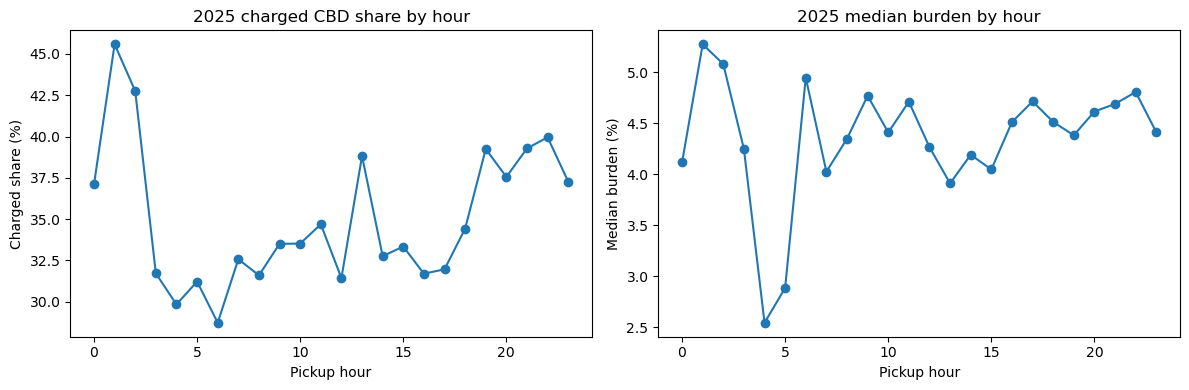

In [28]:
all_2025 = sample[sample["year"].eq(2025)].copy()
charged_2025 = all_2025[all_2025["charged_cbd_flag"]].copy()

exposure_by_hour = (
    all_2025.groupby("pickup_hour", dropna=False)
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "estimated_population": g["sample_weight"].sum(),
        "charged_cbd_share_pct": 100 * weighted_share(g["charged_cbd_flag"], g["sample_weight"]),
        "median_relative_burden_charged_pct": 100 * weighted_quantile(
            g.loc[g["charged_cbd_flag"], "relative_cbd_burden_base_cost"],
            g.loc[g["charged_cbd_flag"], "sample_weight"],
            [0.5],
        )[0],
    }), include_groups=False)
    .reset_index()
)

display(exposure_by_hour.head())
save_table(exposure_by_hour, "hvfhv_exposure_by_hour_2025.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(exposure_by_hour["pickup_hour"], exposure_by_hour["charged_cbd_share_pct"], marker="o")
axes[0].set_title("2025 charged CBD share by hour")
axes[0].set_xlabel("Pickup hour")
axes[0].set_ylabel("Charged share (%)")
axes[1].plot(exposure_by_hour["pickup_hour"], exposure_by_hour["median_relative_burden_charged_pct"], marker="o")
axes[1].set_title("2025 median burden by hour")
axes[1].set_xlabel("Pickup hour")
axes[1].set_ylabel("Median burden (%)")
save_figure("hvfhv_exposure_and_burden_by_hour_2025.png")
plt.show()

,distance_bucket,sample_rows,estimated_population,charged_cbd_share_pct
0,0-1,935.0000,"11,165,816.5480",28.8771
1,1-2,"2,088.0000","24,934,742.9914",30.4119
2,2-5,"2,774.0000","33,126,957.6418",33.9943
3,5-10,"1,550.0000","18,510,006.7852",41.3549
4,10-20,884.0000,"10,556,713.2140",44.9094
5,20+,185.0000,"2,209,224.8196",36.7558


,distance_bucket,sample_rows,estimated_population,charged_cbd_share_pct
0,0-1,935.0000,"11,165,816.5480",28.8771
1,1-2,"2,088.0000","24,934,742.9914",30.4119
2,2-5,"2,774.0000","33,126,957.6418",33.9943
3,5-10,"1,550.0000","18,510,006.7852",41.3549
4,10-20,884.0000,"10,556,713.2140",44.9094
5,20+,185.0000,"2,209,224.8196",36.7558


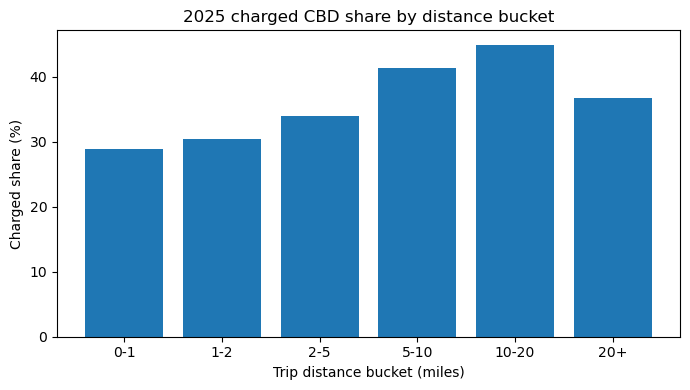

In [29]:
exposure_by_distance_bucket = (
    all_2025.assign(
        distance_bucket=pd.cut(
            all_2025["trip_distance_miles"],
            bins=[0, 1, 2, 5, 10, 20, np.inf],
            labels=["0-1", "1-2", "2-5", "5-10", "10-20", "20+"],
            include_lowest=True,
        )
    )
    .groupby("distance_bucket", observed=False)
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "estimated_population": g["sample_weight"].sum(),
        "charged_cbd_share_pct": 100 * weighted_share(g["charged_cbd_flag"], g["sample_weight"]),
    }), include_groups=False)
    .reset_index()
)

display(exposure_by_distance_bucket)
save_table(exposure_by_distance_bucket, "hvfhv_exposure_by_distance_bucket_2025.csv")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(exposure_by_distance_bucket["distance_bucket"].astype(str), exposure_by_distance_bucket["charged_cbd_share_pct"])
ax.set_title("2025 charged CBD share by distance bucket")
ax.set_xlabel("Trip distance bucket (miles)")
ax.set_ylabel("Charged share (%)")
save_figure("hvfhv_exposure_by_distance_bucket_2025.png")
plt.show()

In [30]:
top_od_charged = (
    charged_2025.groupby(["PULocationID", "DOLocationID"], dropna=False)
    .agg(sample_rows=("sample_row_id", "size"), estimated_population=("sample_weight", "sum"))
    .reset_index()
    .sort_values("estimated_population", ascending=False)
    .head(20)
)

display(top_od_charged)
save_table(top_od_charged, "hvfhv_top_od_charged_2025.csv")

,PULocationID,DOLocationID,sample_rows,estimated_population
201,48,265,12,"143,298.6006"
1212,164,265,12,"143,293.7077"
1166,163,265,9,"107,478.7984"
762,138,230,9,"107,474.4315"
1512,230,265,9,"107,472.4627"
1254,170,138,8,"95,539.3618"
1125,162,265,8,"95,527.9052"
576,107,265,8,"95,524.9812"
1157,163,236,7,"83,595.2112"
1375,211,170,7,"83,594.8533"


,PULocationID,DOLocationID,sample_rows,estimated_population
201,48,265,12,"143,298.6006"
1212,164,265,12,"143,293.7077"
1166,163,265,9,"107,478.7984"
762,138,230,9,"107,474.4315"
1512,230,265,9,"107,472.4627"
1254,170,138,8,"95,539.3618"
1125,162,265,8,"95,527.9052"
576,107,265,8,"95,524.9812"
1157,163,236,7,"83,595.2112"
1375,211,170,7,"83,594.8533"


## 13. Outliers and Distribution Shape

This section examines distribution shape and outlier characteristics for key continuous variables. Domain-based flags remain the primary data-quality rules; the tools here are supporting diagnostics.

In [31]:
outlier_cols = [
    "passenger_cost_pretip",
    "trip_distance_miles",
    "trip_duration_minutes",
    "driver_pay",
    "gross_cost_per_mile",
    "driver_pay_per_hour",
]

outlier_rows = []
for col in outlier_cols:
    x = sample[col].replace([np.inf, -np.inf], np.nan).dropna()
    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1
    median = x.median()
    mad = (x - median).abs().median()
    outlier_rows.append({
        "variable": col,
        "sample_rows_nonmissing": len(x),
        "p01": x.quantile(0.01),
        "p25": q1,
        "median": median,
        "p75": q3,
        "p99": x.quantile(0.99),
        "iqr_upper_fence": q3 + 1.5 * iqr,
        "iqr_outlier_rows": int((x > q3 + 1.5 * iqr).sum()),
        "mad": mad,
    })

outlier_summary = pd.DataFrame(outlier_rows)
display(outlier_summary)
save_table(outlier_summary, "hvfhv_outlier_summary.csv")

,variable,sample_rows_nonmissing,p01,p25,median,p75,p99,iqr_upper_fence,iqr_outlier_rows,mad
0,passenger_cost_pretip,16889,7.4588,14.9000,23.0100,38.6200,142.9832,74.2000,1162,10.0400
1,trip_distance_miles,16889,0.4900,1.5420,2.9400,6.2000,26.1736,13.1870,1242,1.7200
2,trip_duration_minutes,16889,3.2667,9.8833,16.0167,25.4333,68.6893,48.7583,731,7.0833
3,driver_pay,16889,4.0700,8.9500,15.1000,25.3600,81.8084,49.9750,961,7.2400
4,gross_cost_per_mile,16888,2.9099,5.5202,7.5000,10.7535,34.6312,18.6035,1015,2.3631
5,driver_pay_per_hour,16889,39.7200,49.3645,55.5115,66.5917,139.8065,92.4325,942,7.5604


,variable,sample_rows_nonmissing,p01,p25,median,p75,p99,iqr_upper_fence,iqr_outlier_rows,mad
0,passenger_cost_pretip,16889,7.4588,14.9000,23.0100,38.6200,142.9832,74.2000,1162,10.0400
1,trip_distance_miles,16889,0.4900,1.5420,2.9400,6.2000,26.1736,13.1870,1242,1.7200
2,trip_duration_minutes,16889,3.2667,9.8833,16.0167,25.4333,68.6893,48.7583,731,7.0833
3,driver_pay,16889,4.0700,8.9500,15.1000,25.3600,81.8084,49.9750,961,7.2400
4,gross_cost_per_mile,16888,2.9099,5.5202,7.5000,10.7535,34.6312,18.6035,1015,2.3631
5,driver_pay_per_hour,16889,39.7200,49.3645,55.5115,66.5917,139.8065,92.4325,942,7.5604


In [32]:
high_burden_sample = (
    sample[sample["burden_analysis_flag"]]
    .sort_values("relative_cbd_burden_base_cost", ascending=False)
    [[
        "year",
        "month",
        "provider_label",
        "PULocationID",
        "DOLocationID",
        "trip_distance_miles",
        "trip_duration_minutes",
        "passenger_cost_pretip",
        "cbd_congestion_fee",
        "base_cost_ex_cbd",
        "relative_cbd_burden_base_cost",
        "driver_pay",
        "possible_refund_or_adjustment_flag",
    ]]
    .head(25)
)

display(high_burden_sample)

,year,month,provider_label,PULocationID,DOLocationID,trip_distance_miles,trip_duration_minutes,passenger_cost_pretip,cbd_congestion_fee,base_cost_ex_cbd,relative_cbd_burden_base_cost,driver_pay,possible_refund_or_adjustment_flag
12472,2025,4,Lyft,158,246,1.0570,4.9167,10.9900,1.5000,9.4900,0.1581,4.4900,False
11617,2025,3,Lyft,68,186,0.7910,5.6500,10.9900,1.5000,9.4900,0.1581,4.5600,False
14752,2025,5,Lyft,79,4,0.7430,3.9167,10.9900,1.5000,9.4900,0.1581,4.0000,False
12201,2025,4,Lyft,246,68,0.4550,4.9333,10.9900,1.5000,9.4900,0.1581,4.0000,False
8975,2025,2,Uber,79,4,0.7500,7.2167,11.1400,1.5000,9.6400,0.1556,5.2300,False
12807,2025,4,Uber,79,234,0.9300,8.2167,11.5300,1.5000,10.0300,0.1496,7.0200,False
13273,2025,4,Lyft,90,68,0.7200,5.0000,11.6900,1.5000,10.1900,0.1472,5.3100,False
10584,2025,3,Lyft,107,107,0.3640,4.4333,11.7500,1.5000,10.2500,0.1463,4.0000,False
13205,2025,4,Lyft,232,4,0.5870,3.8833,11.7500,1.5000,10.2500,0.1463,4.0000,False
13158,2025,4,Lyft,249,249,0.8130,5.5667,11.8100,1.5000,10.3100,0.1455,4.5400,False


## 14. Decisions and Pending Validations

This section consolidates EDA findings into two parts:

1. **Data processing decisions:** flag and subset choices confirmed by the EDA and carried into the exported helper dataset.
2. **Pending full-data validations:** patterns observed in the 20K sample that require verification on the full cleaned dataset before being interpreted as real signals.

In [33]:
from pathlib import Path

import numpy as np
import pandas as pd

if "REPO_ROOT" not in globals():
    CWD = Path.cwd().resolve()
    for candidate in [CWD, CWD.parent]:
        if (candidate / "data" / "processed" / "samples").exists():
            REPO_ROOT = candidate
            break
    else:
        raise FileNotFoundError("Could not locate the repository root.")

if "sample" not in globals():
    export_path = REPO_ROOT / "data" / "processed" / "samples" / "hvfhv_trip_level_sample_eda_features.csv"
    sample = pd.read_csv(export_path, parse_dates=["pickup_datetime", "dropoff_datetime"])
    print(f"Loaded EDA-ready HVFHV sample from {export_path.relative_to(REPO_ROOT)}")

if "weighted_share" not in globals():
    def weighted_share(mask, w):
        mask = pd.Series(mask, index=w.index).fillna(False).astype(bool)
        w = pd.to_numeric(w, errors="coerce")
        valid = w.notna() & w.gt(0)
        if valid.sum() == 0:
            return np.nan
        return w[valid & mask].sum() / w[valid].sum()

refund_adjustment_flag = (
    sample["possible_refund_or_adjustment_flag"].fillna(False).astype(bool)
    if "possible_refund_or_adjustment_flag" in sample.columns
    else pd.Series(False, index=sample.index)
)

main_subset_summary = pd.Series({
    "all_hvfhv_sample_rows": len(sample),
    "main_analysis_rows": int(sample["main_analysis_flag"].sum()),
    "main_analysis_row_share_pct_unweighted": 100 * sample["main_analysis_flag"].mean(),
    "main_analysis_share_pct_weighted": 100 * weighted_share(sample["main_analysis_flag"], sample["sample_weight"]),
    "burden_analysis_rows_2025_charged": int(sample["burden_analysis_flag"].sum()),
    "burden_analysis_share_pct_weighted": 100 * weighted_share(sample["burden_analysis_flag"], sample["sample_weight"]),
    "distance_rate_analysis_rows": int(sample["distance_rate_analysis_flag"].sum()),
    "shared_request_share_pct_weighted": 100 * weighted_share(sample["shared_request_yes_flag"], sample["sample_weight"]),
    "possible_refund_or_adjustment_share_pct_weighted": 100 * weighted_share(refund_adjustment_flag, sample["sample_weight"]),
})

main_subset_summary.to_frame("value")

,value
all_hvfhv_sample_rows,"16,889.0000"
main_analysis_rows,"16,889.0000"
main_analysis_row_share_pct_unweighted,100.0000
main_analysis_share_pct_weighted,100.0000
burden_analysis_rows_2025_charged,"2,954.0000"
burden_analysis_share_pct_weighted,17.4900
distance_rate_analysis_rows,"16,888.0000"
shared_request_share_pct_weighted,3.2270
possible_refund_or_adjustment_share_pct_weighted,0.0059


**Data processing decisions from this sample:**

- Use `main_analysis_flag` for broad descriptive analysis.
- Use `burden_analysis_flag` for post-policy burden analysis: 2025 charged trips with positive base cost excluding CBD fee.
- Use `distance_rate_analysis_flag` for per-mile and speed analyses.
- Retain provider and shared-ride labels as descriptive regime fields.
- Keep component reliability flags so later analysis can separate clean component totals from adjustment/refund-like rows.

**Pending full-data validations:**

- Confirm monthly CBD fee values and charged shares on full HVFHV data.
- Confirm provider mix and shared-ride composition on full HVFHV data.
- Recheck zone rankings using full-data aggregates before making geographic claims.
- Validate high-burden and low-denominator patterns outside this 20K sample.

In [34]:
from pathlib import Path

import pandas as pd

if "REPO_ROOT" not in globals():
    CWD = Path.cwd().resolve()
    for candidate in [CWD, CWD.parent]:
        if (candidate / "data" / "processed" / "samples").exists():
            REPO_ROOT = candidate
            break
    else:
        raise FileNotFoundError("Could not locate the repository root.")

if "sample" not in globals():
    export_path = REPO_ROOT / "data" / "processed" / "samples" / "hvfhv_trip_level_sample_eda_features.csv"
    sample = pd.read_csv(export_path, parse_dates=["pickup_datetime", "dropoff_datetime"])
    print(f"Loaded EDA-ready HVFHV sample from {export_path.relative_to(REPO_ROOT)}")

export_columns = [
    "sample_row_id",
    "sample_weight",
    "year",
    "month",
    "pickup_datetime",
    "dropoff_datetime",
    "pickup_hour",
    "pickup_weekday",
    "PULocationID",
    "DOLocationID",
    "hvfhs_license_num",
    "provider_label",
    "trip_distance_miles",
    "trip_duration_seconds",
    "trip_duration_minutes",
    "cbd_congestion_fee",
    "charged_cbd_flag",
    "passenger_cost_pretip",
    "passenger_cost_excl_cbd",
    "base_cost_ex_cbd",
    "relative_cbd_burden_current_cost",
    "relative_cbd_burden_base_cost",
    "gross_cost_per_mile",
    "base_passenger_fare",
    "bcf",
    "sales_tax",
    "congestion_surcharge",
    "tolls",
    "airport_fee",
    "tips",
    "driver_pay",
    "driver_pay_per_mile",
    "driver_pay_per_hour",
    "speed_mph",
    "shared_request_normalized",
    "shared_match_normalized",
    "shared_request_yes_flag",
    "shared_match_yes_flag",
    "component_missing_flag",
    "any_negative_available_component_flag",
    "mixed_sign_available_component_flag",
    "component_total_diff",
    "component_total_match_flag",
    "main_analysis_flag",
    "burden_analysis_flag",
    "distance_rate_analysis_flag",
]

missing_export_columns = [c for c in export_columns if c not in sample.columns]
if missing_export_columns:
    raise KeyError(
        "Missing EDA export columns. Run the setup and feature-creation cells above "
        f"before exporting. Missing: {missing_export_columns}"
    )

export_path = REPO_ROOT / "data" / "processed" / "samples" / "hvfhv_trip_level_sample_eda_features.csv"
sample[export_columns].to_csv(export_path, index=False)

print(f"Saved EDA-ready sample: {export_path.relative_to(REPO_ROOT)}")
print(f"Rows: {len(sample):,}; columns: {len(export_columns)}")

Saved EDA-ready sample: data/processed/samples/hvfhv_trip_level_sample_eda_features.csv
Rows: 16,889; columns: 46


## Summary

This HVFHV notebook now mirrors the Yellow Taxi EDA's structure while adapting the content to HVFHV-specific regimes and variables. The main outputs are diagnostic tables/figures plus an EDA-ready helper CSV with analysis flags and derived metrics.